<a href="https://www.kaggle.com/code/lalit7881/impact-of-social-media-on-life-eda-99-79?scriptVersionId=350768208" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harishyadav0506/impact-of-social-media-on-life/Social_media_impact_on_life.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harishyadav0506/impact-of-social-media-on-life/Social_media_impact_on_life.csv")

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
4495,STU_2028495,16,Male,High School,YouTube,5.8,1.2,Smartphone,7.8,3,True,Sometimes,11.0,79,2.85,Beneficial
4496,STU_2028496,19,Female,Undergraduate,LinkedIn,3.8,3.0,Smartphone,6.6,3,False,Frequently,9.0,83,3.37,Beneficial
4497,STU_2028497,19,Male,Undergraduate,Instagram,7.7,1.1,Smartphone,6.0,2,True,Frequently,13.0,73,3.16,Beneficial
4498,STU_2028498,16,Male,High School,LinkedIn,4.6,3.3,Laptop/PC,7.1,3,False,Sometimes,22.0,87,3.50,Beneficial
4499,STU_2028499,24,Male,Undergraduate,Instagram,1.8,2.1,Smartphone,6.8,3,True,Frequently,10.0,98,3.73,Beneficial


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

In [6]:
df.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4454.000000,4500.000000,4415.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,13.512124,79.873111,3.429282
std,1.981182,2.604497,0.699245,1.189998,1.030484,7.072859,12.876044,0.392662
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,32.000000,1.900000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,9.000000,72.000000,3.200000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,13.000000,82.000000,3.460000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,18.000000,89.000000,3.720000
max,26.000000,14.000000,4.500000,10.500000,5.000000,40.000000,98.000000,4.000000


In [7]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Student_ID                      object
Age                              int64
Gender                          object
Academic_Level                  object
Primary_Platform                object
Daily_Usage_Hours              float64
Weekend_Extra_Hours            float64
Device_Type                     object
Sleep_Duration_Hours           float64
Sleep_Quality_Score              int64
Late_Night_Usage                  bool
Social_Comparison_Frequency     object
Perceived_Stress_Score         float64
Mental_Health_Index              int64
Academic_Performance_GPA       float64
Overall_Impact                  object
dtype: object

In [10]:
df.shape

(4500, 16)

In [11]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Primary_Platform',
       'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Device_Type',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage',
       'Social_Comparison_Frequency', 'Perceived_Stress_Score',
       'Mental_Health_Index', 'Academic_Performance_GPA', 'Overall_Impact'],
      dtype='object')

In [12]:
df.nunique()

Student_ID                     4500
Age                              12
Gender                            4
Academic_Level                    3
Primary_Platform                  7
Daily_Usage_Hours               129
Weekend_Extra_Hours              43
Device_Type                       3
Sleep_Duration_Hours             73
Sleep_Quality_Score               5
Late_Night_Usage                  2
Social_Comparison_Frequency       5
Perceived_Stress_Score           41
Mental_Health_Index              67
Academic_Performance_GPA        194
Overall_Impact                    3
dtype: int64

## EDA

DATASET SHAPE
(4500, 16)

COLUMN NAMES
Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Primary_Platform',
       'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Device_Type',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage',
       'Social_Comparison_Frequency', 'Perceived_Stress_Score',
       'Mental_Health_Index', 'Academic_Performance_GPA', 'Overall_Impact'],
      dtype='object')

FIRST 5 ROWS
    Student_ID  Age  Gender Academic_Level Primary_Platform  \
0  STU_2024000   19  Female  Undergraduate         Snapchat   
1  STU_2024001   19  Female  Undergraduate        Instagram   
2  STU_2024002   17  Female    High School           TikTok   
3  STU_2024003   16  Female    High School          YouTube   
4  STU_2024004   17    Male    High School         LinkedIn   

   Daily_Usage_Hours  Weekend_Extra_Hours Device_Type  Sleep_Duration_Hours  \
0                7.5                  1.5  Smartphone                   5.9   
1                4.6           

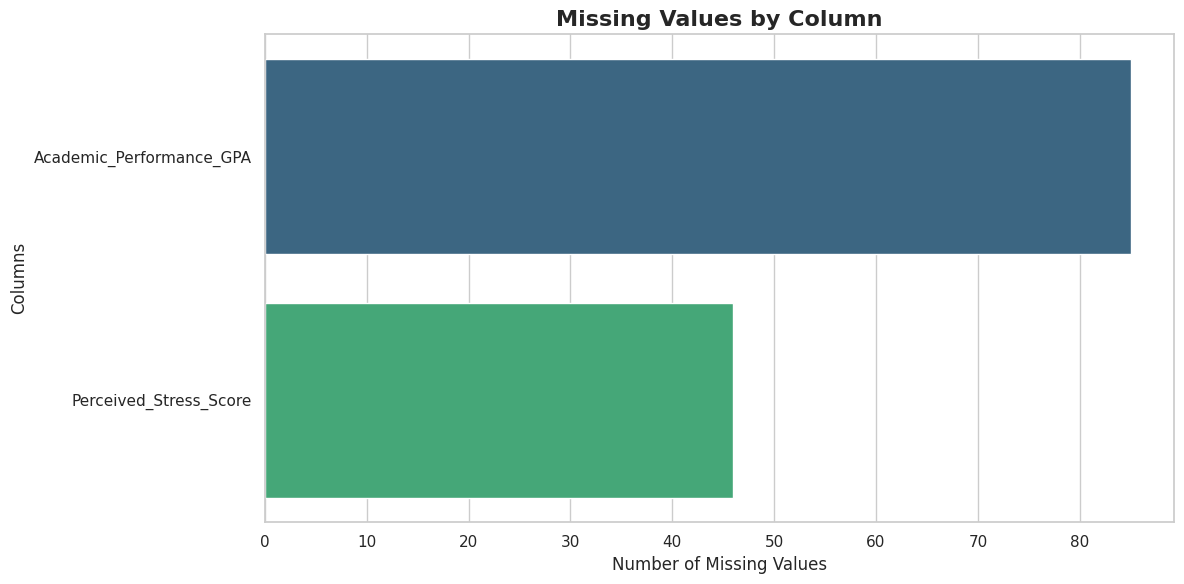


Numeric Columns:
['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 'Mental_Health_Index', 'Academic_Performance_GPA']

Categorical Columns:
['Student_ID', 'Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type', 'Social_Comparison_Frequency', 'Overall_Impact']


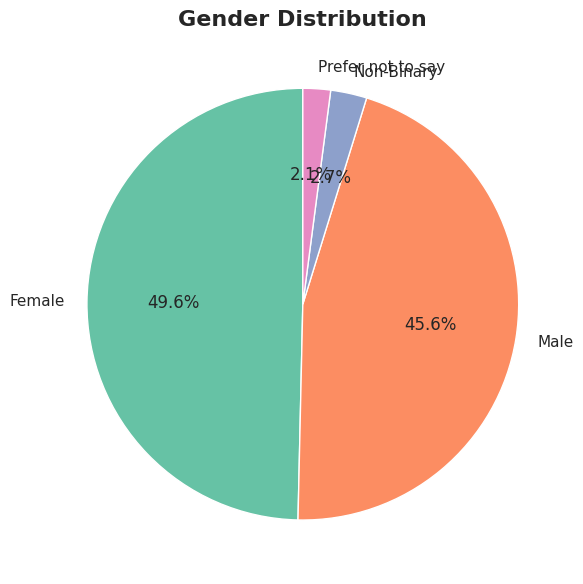

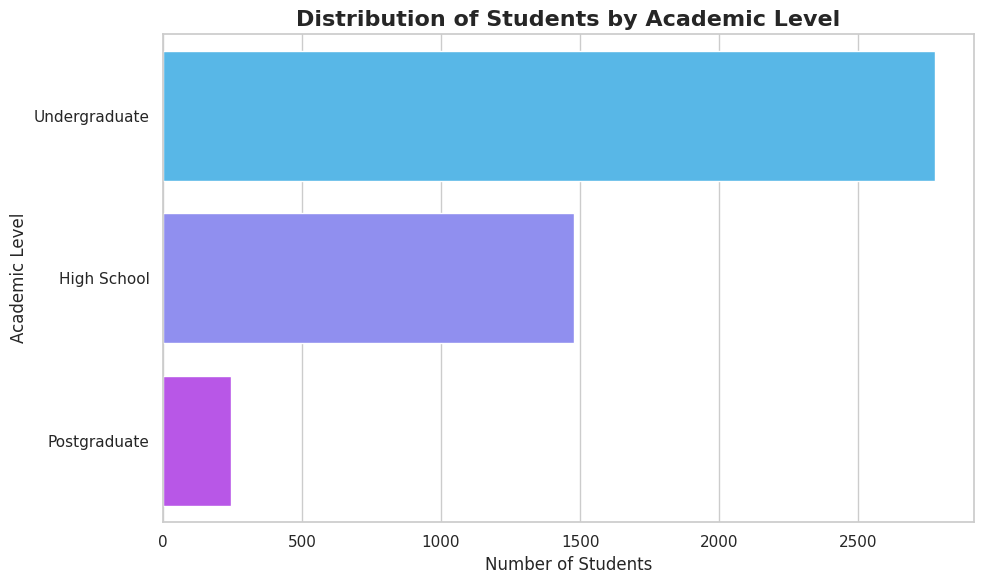

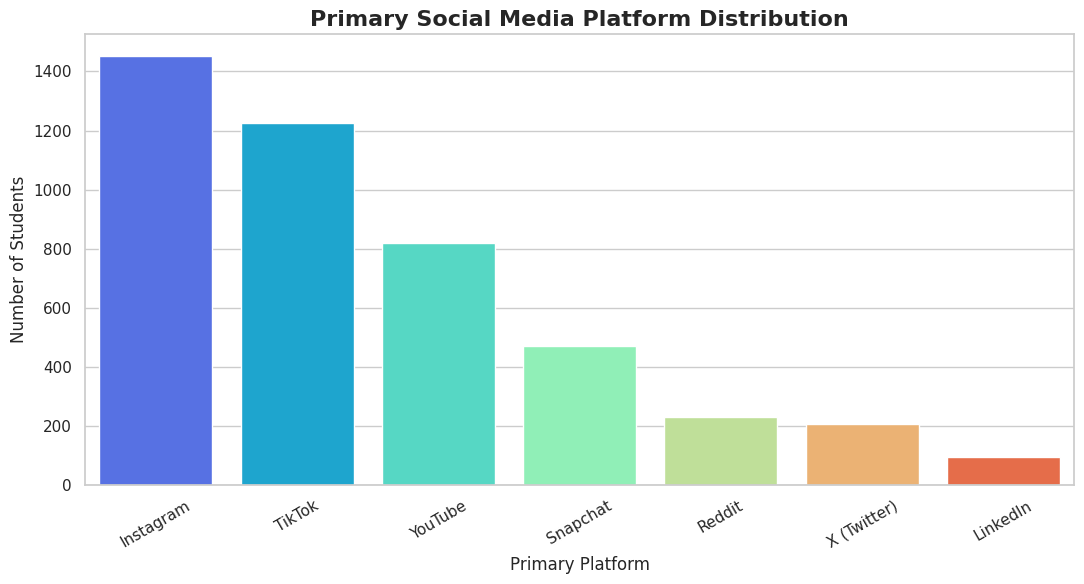

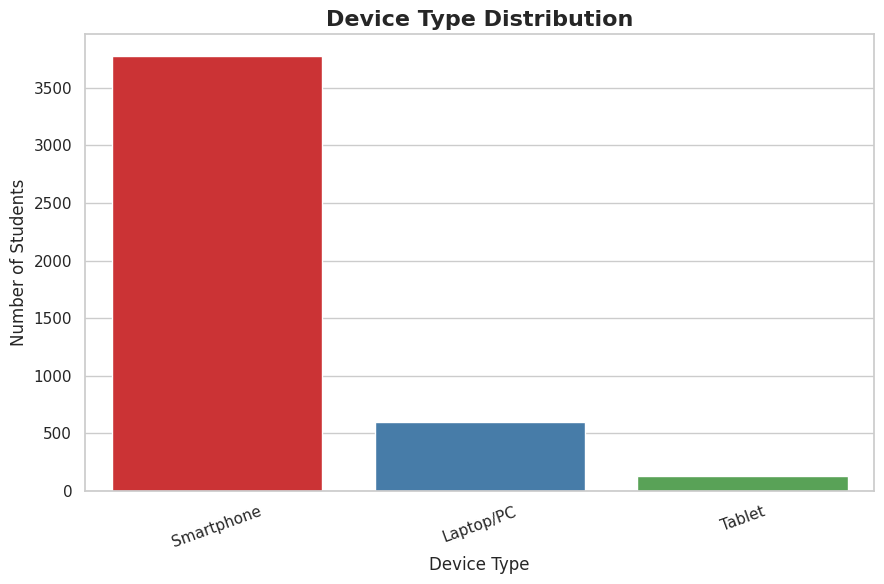

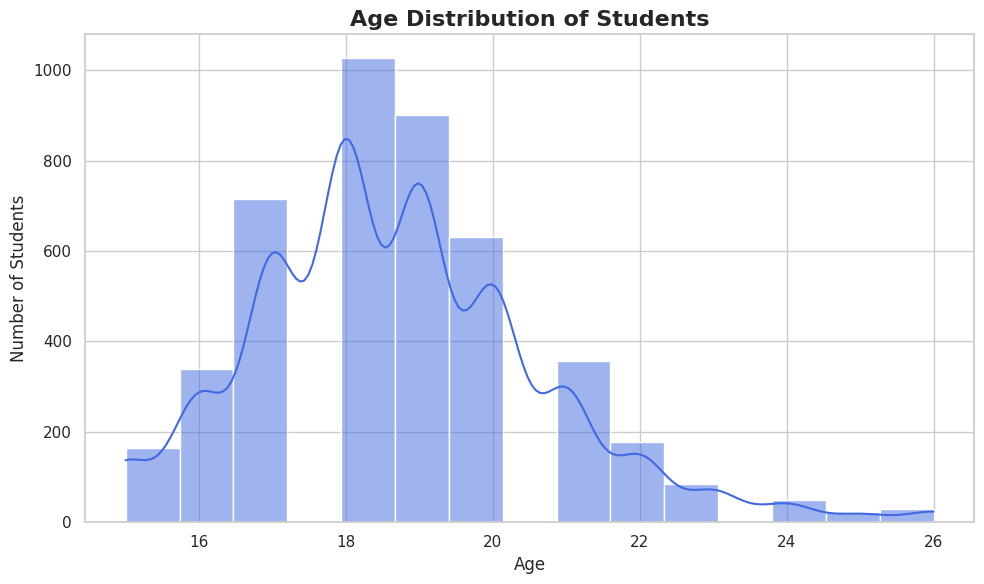

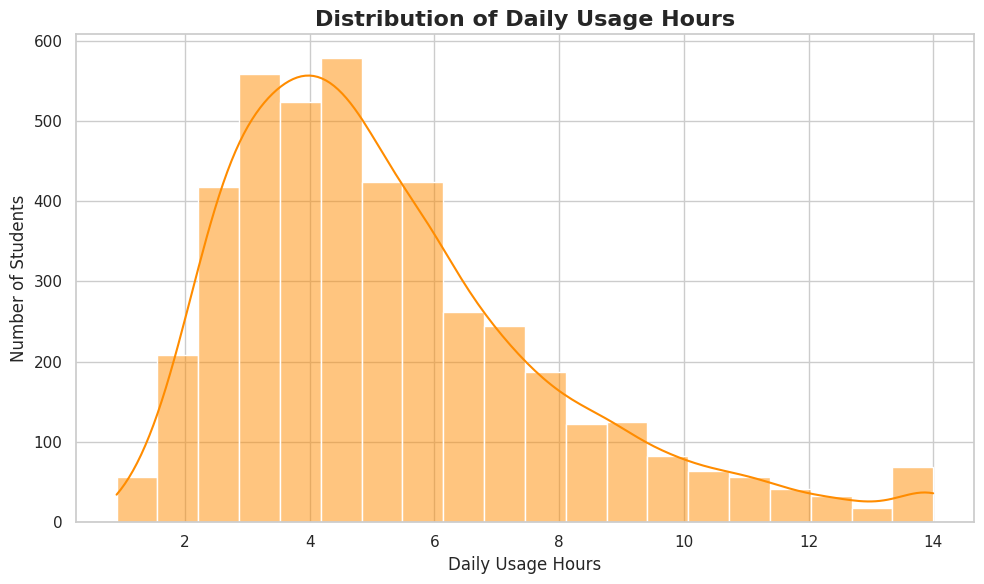

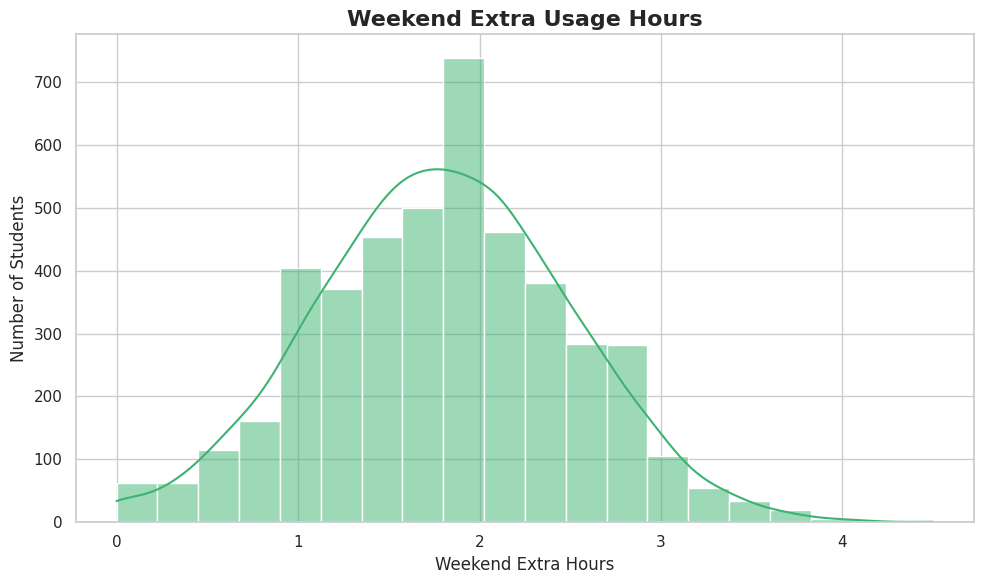

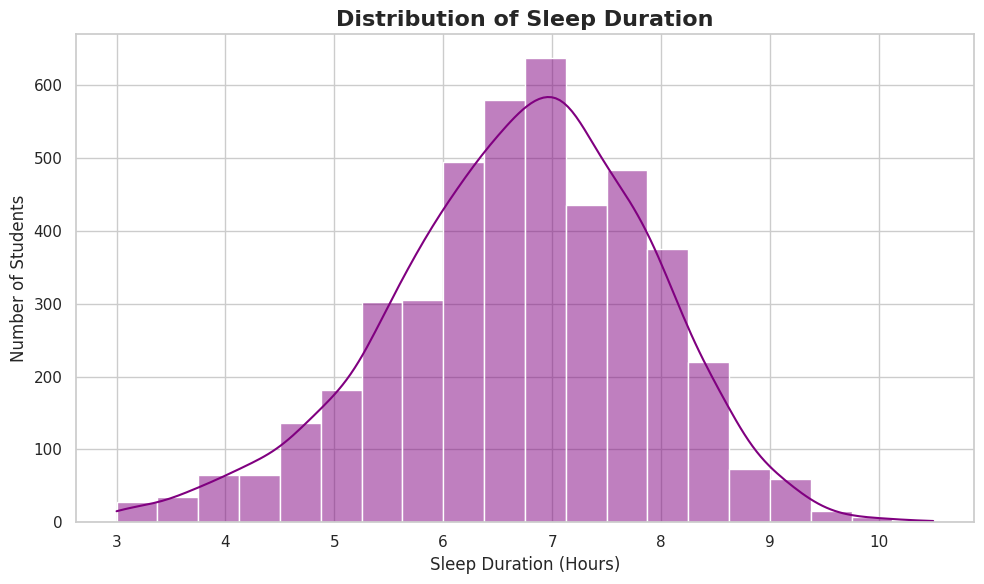

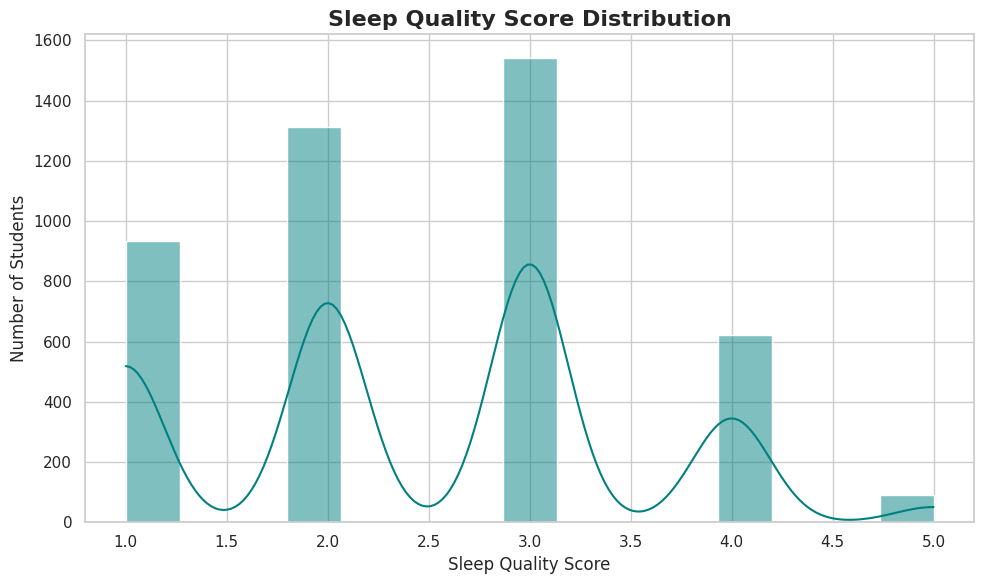

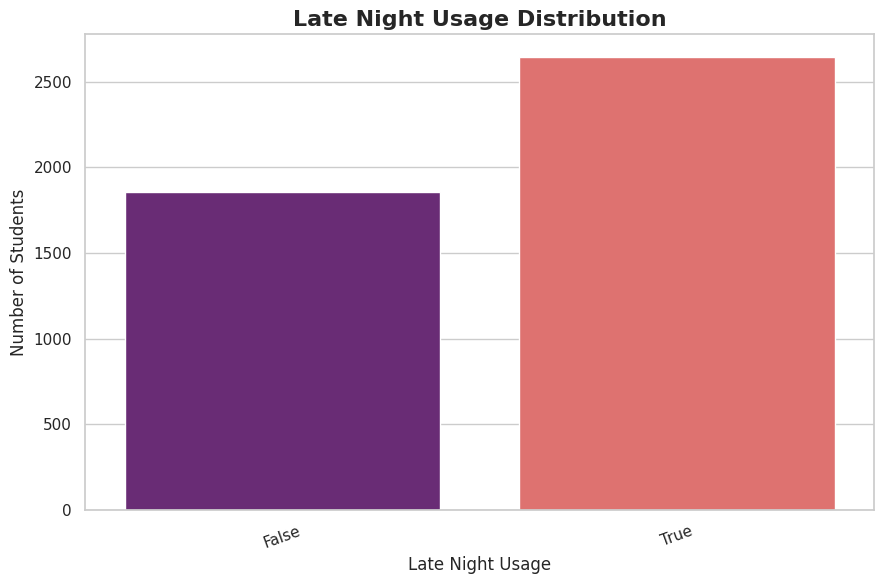

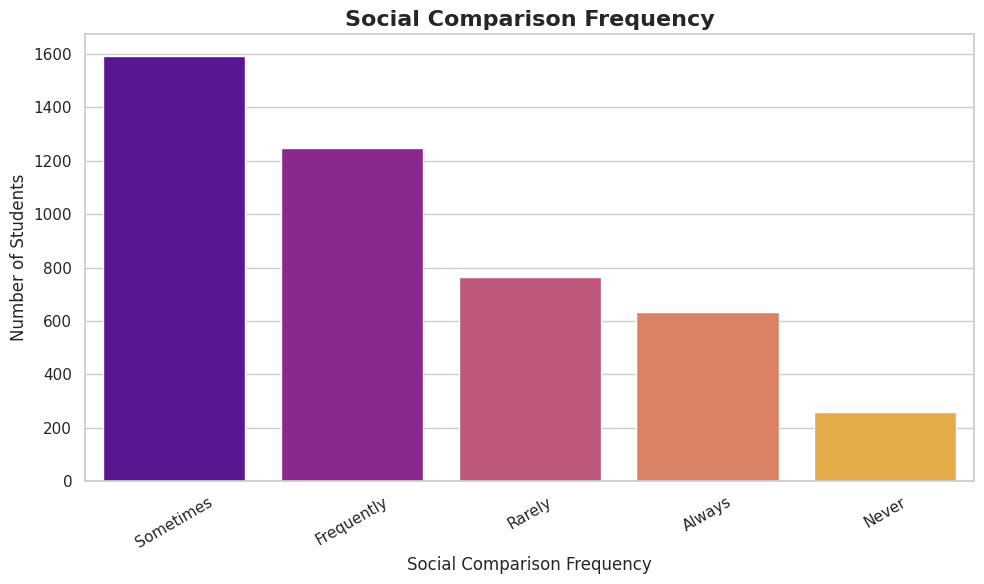

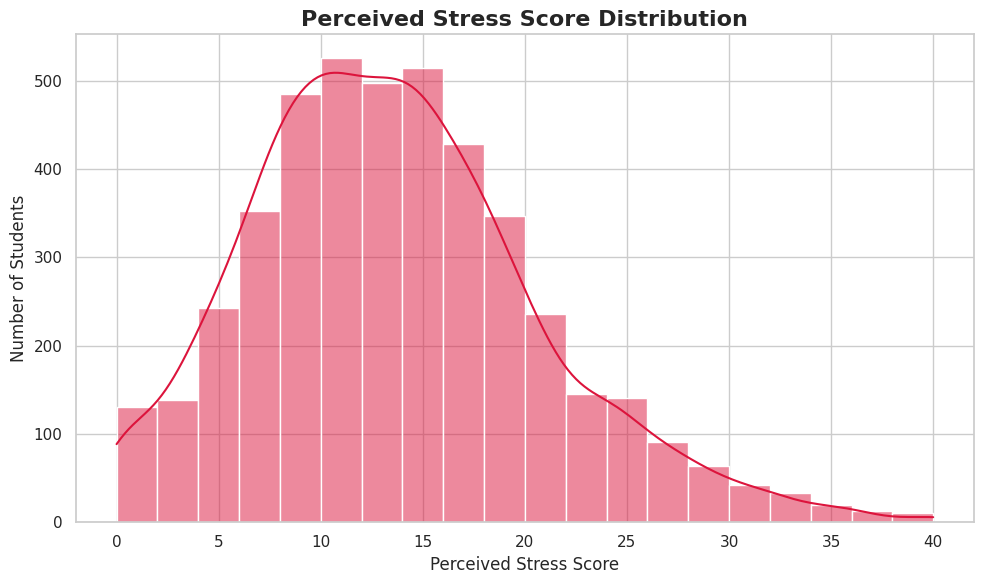

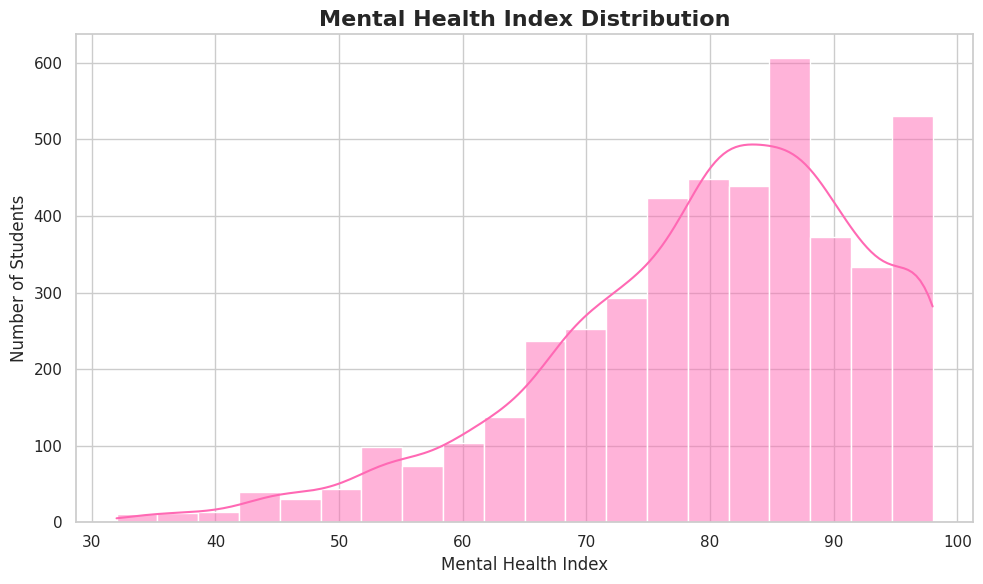

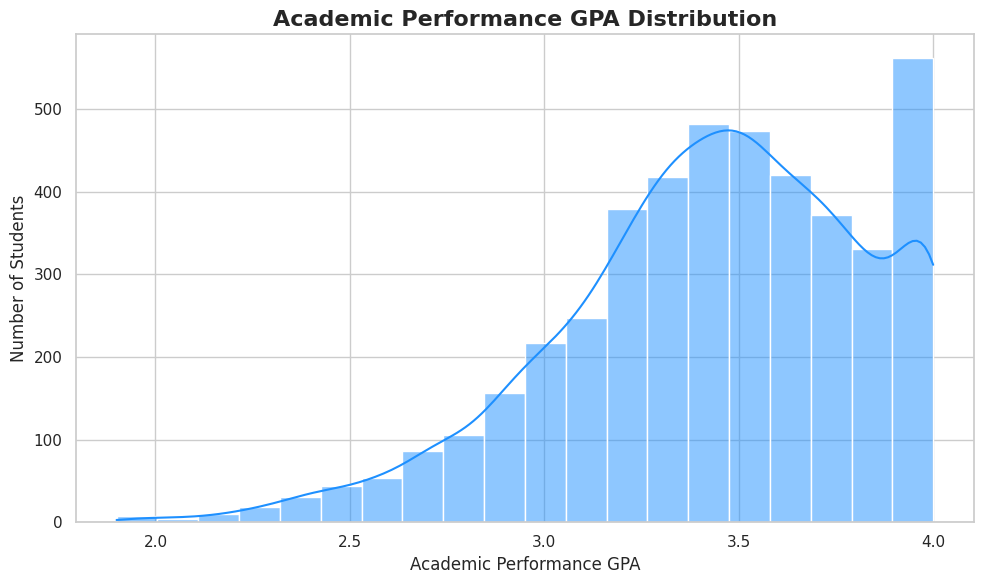

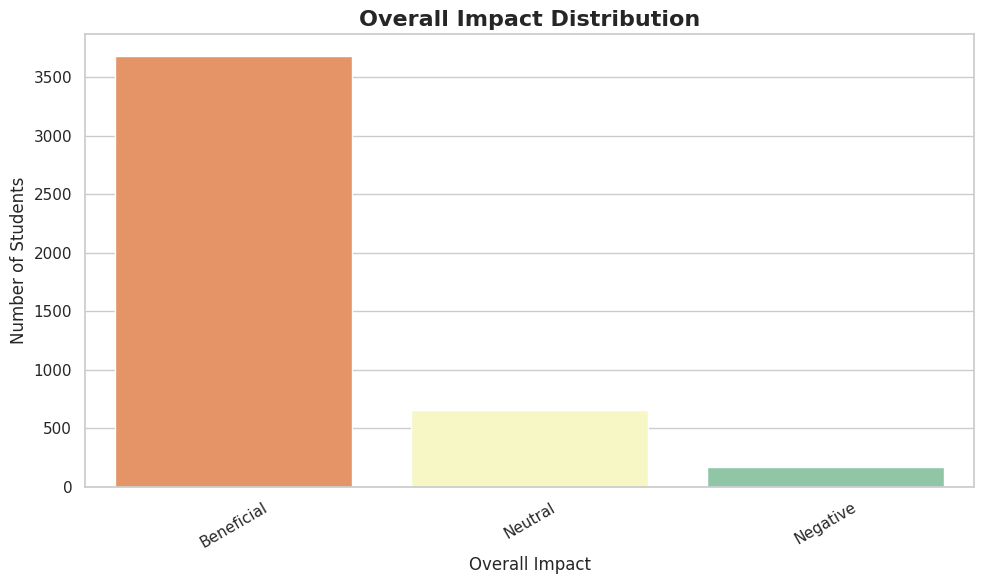

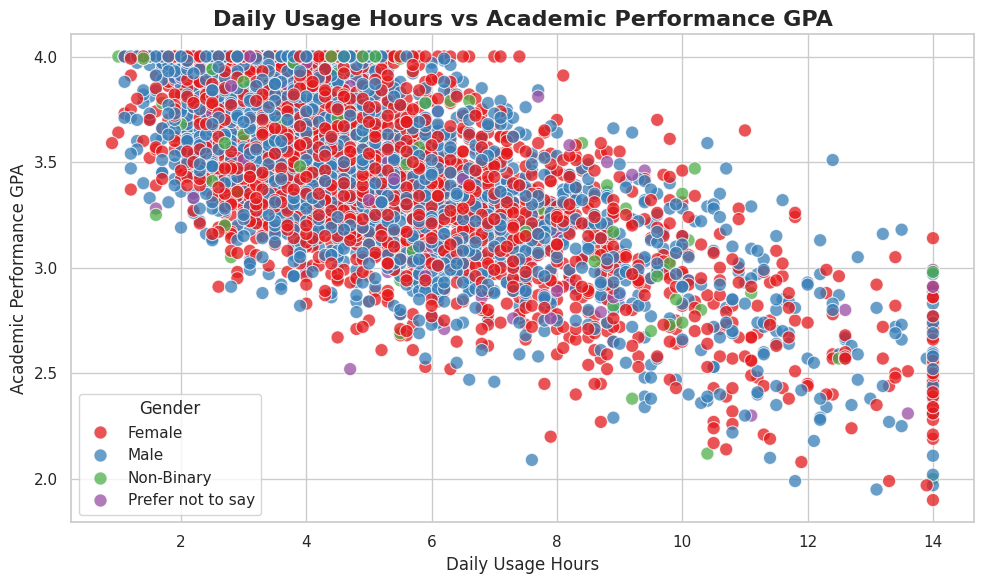

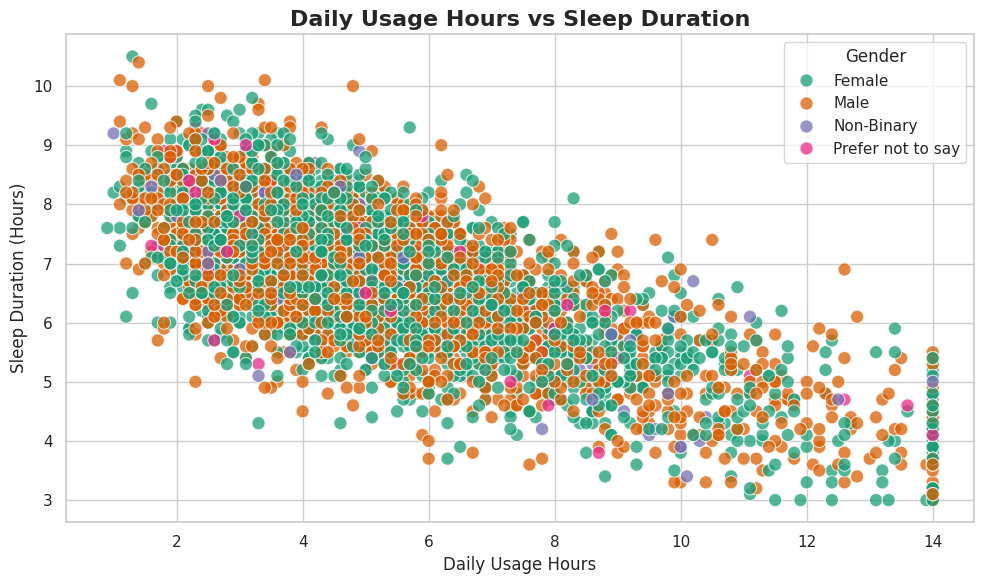

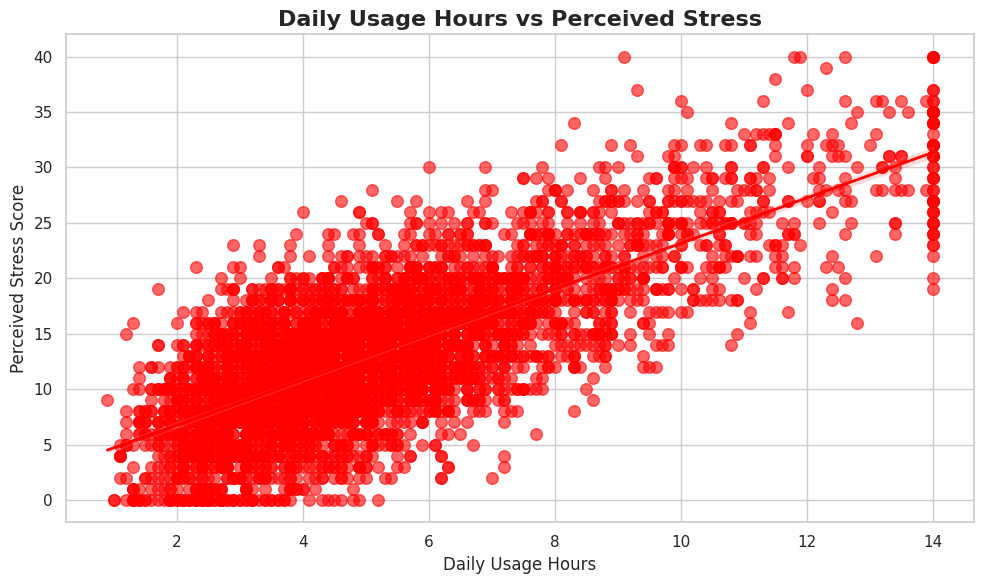

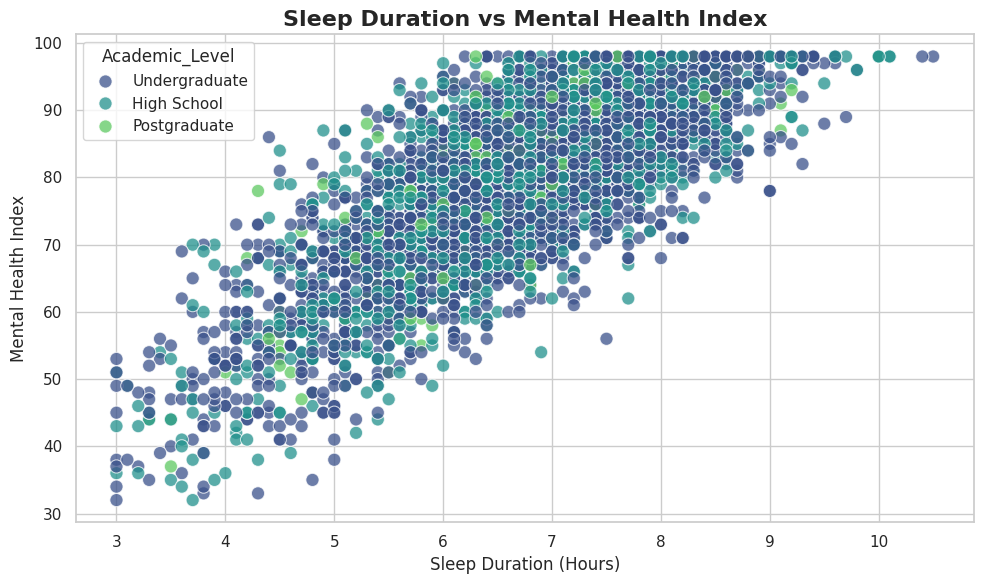

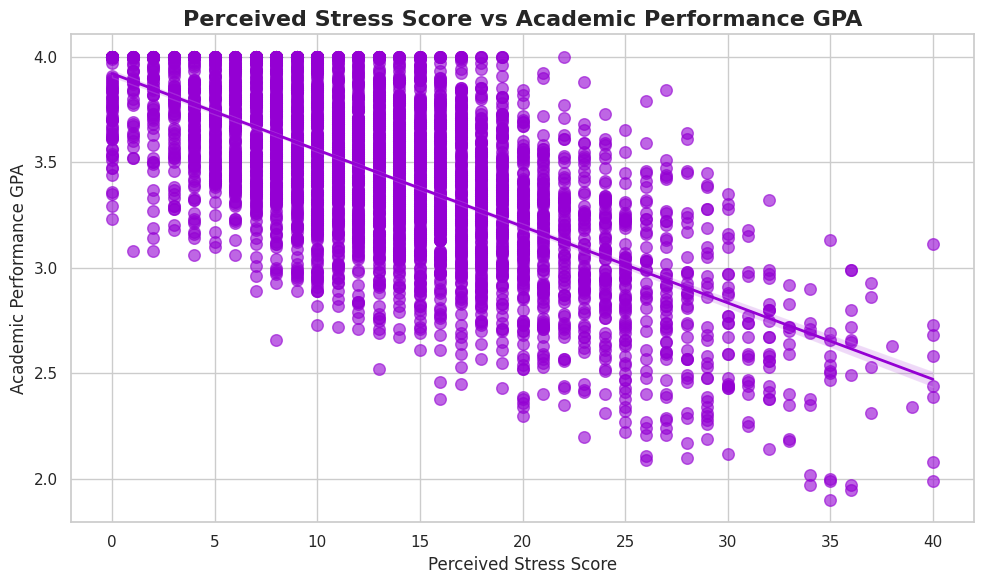

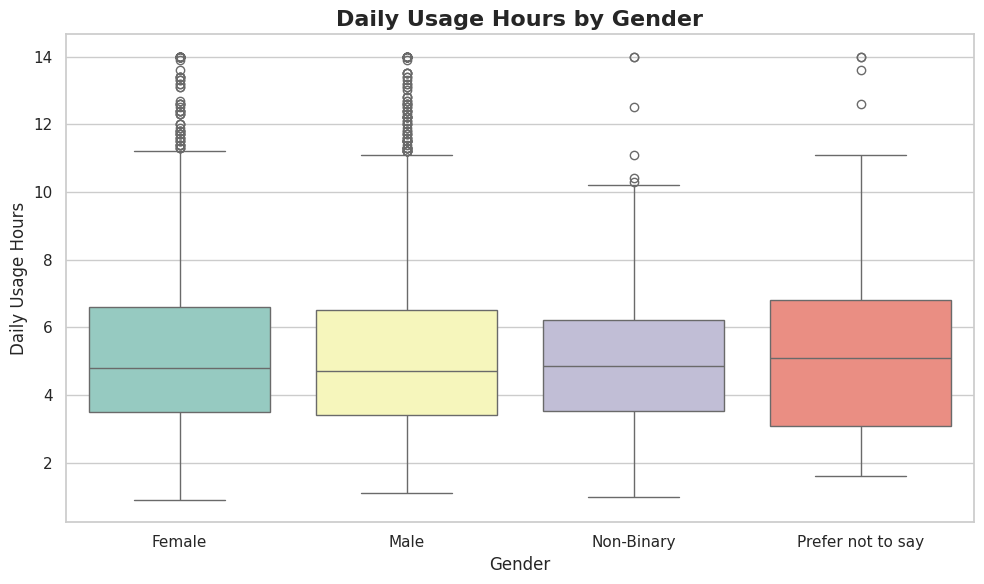

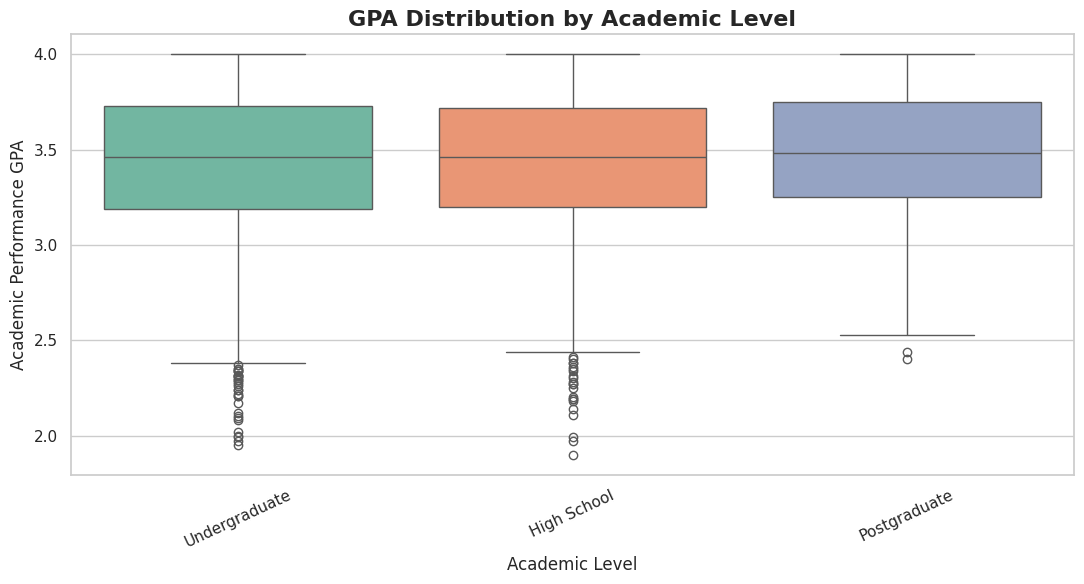

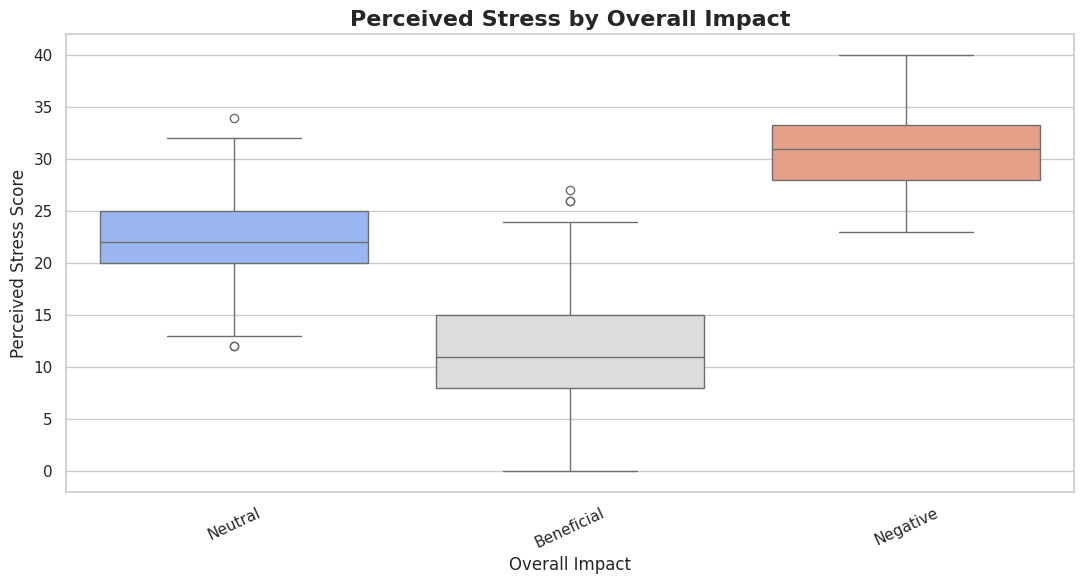

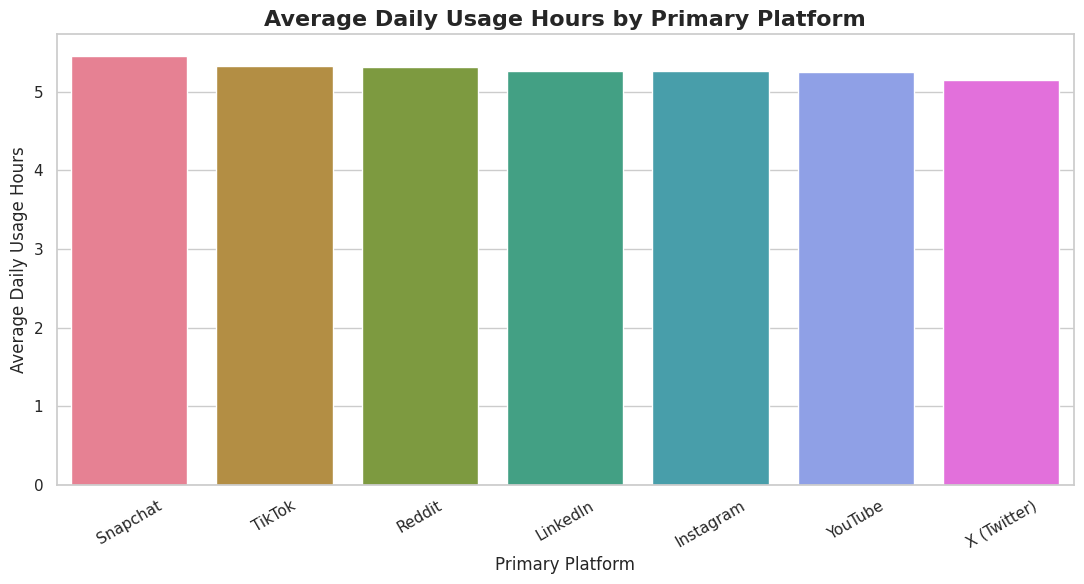

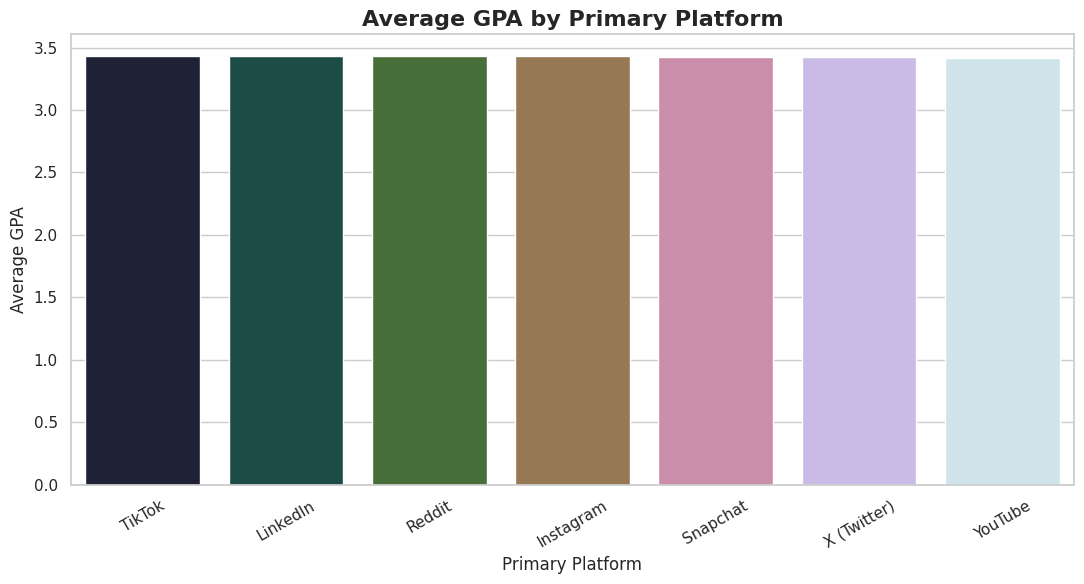

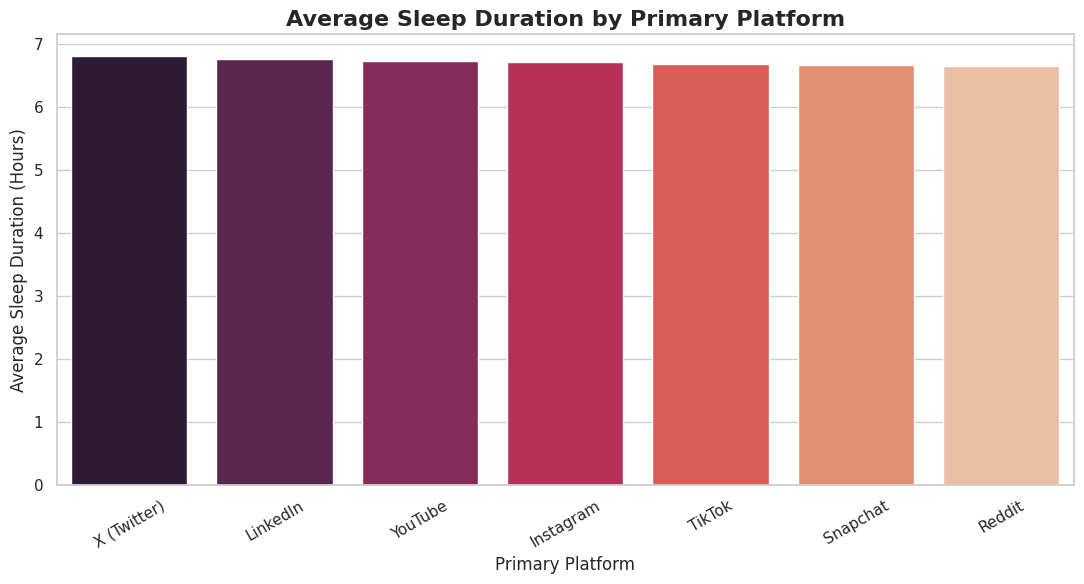

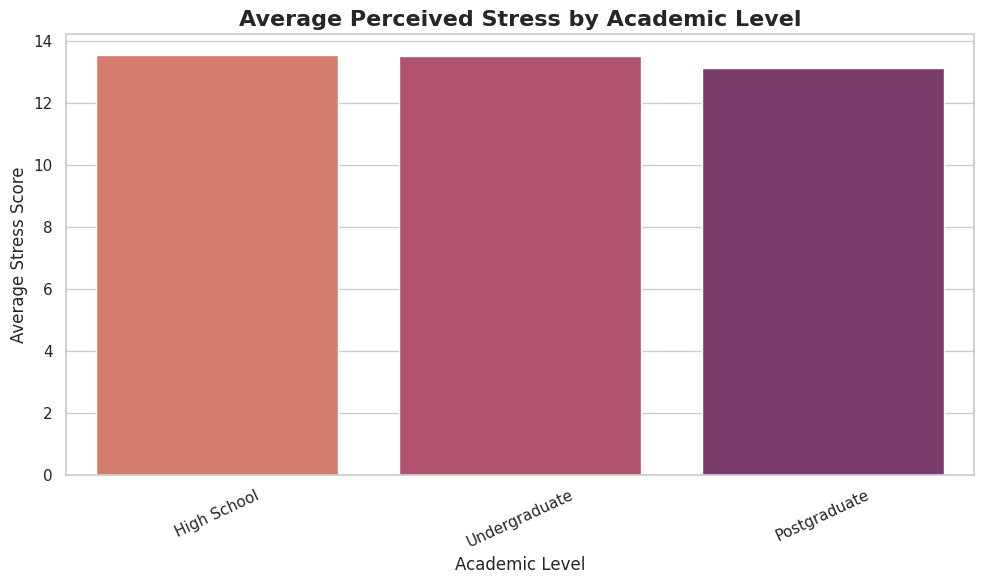

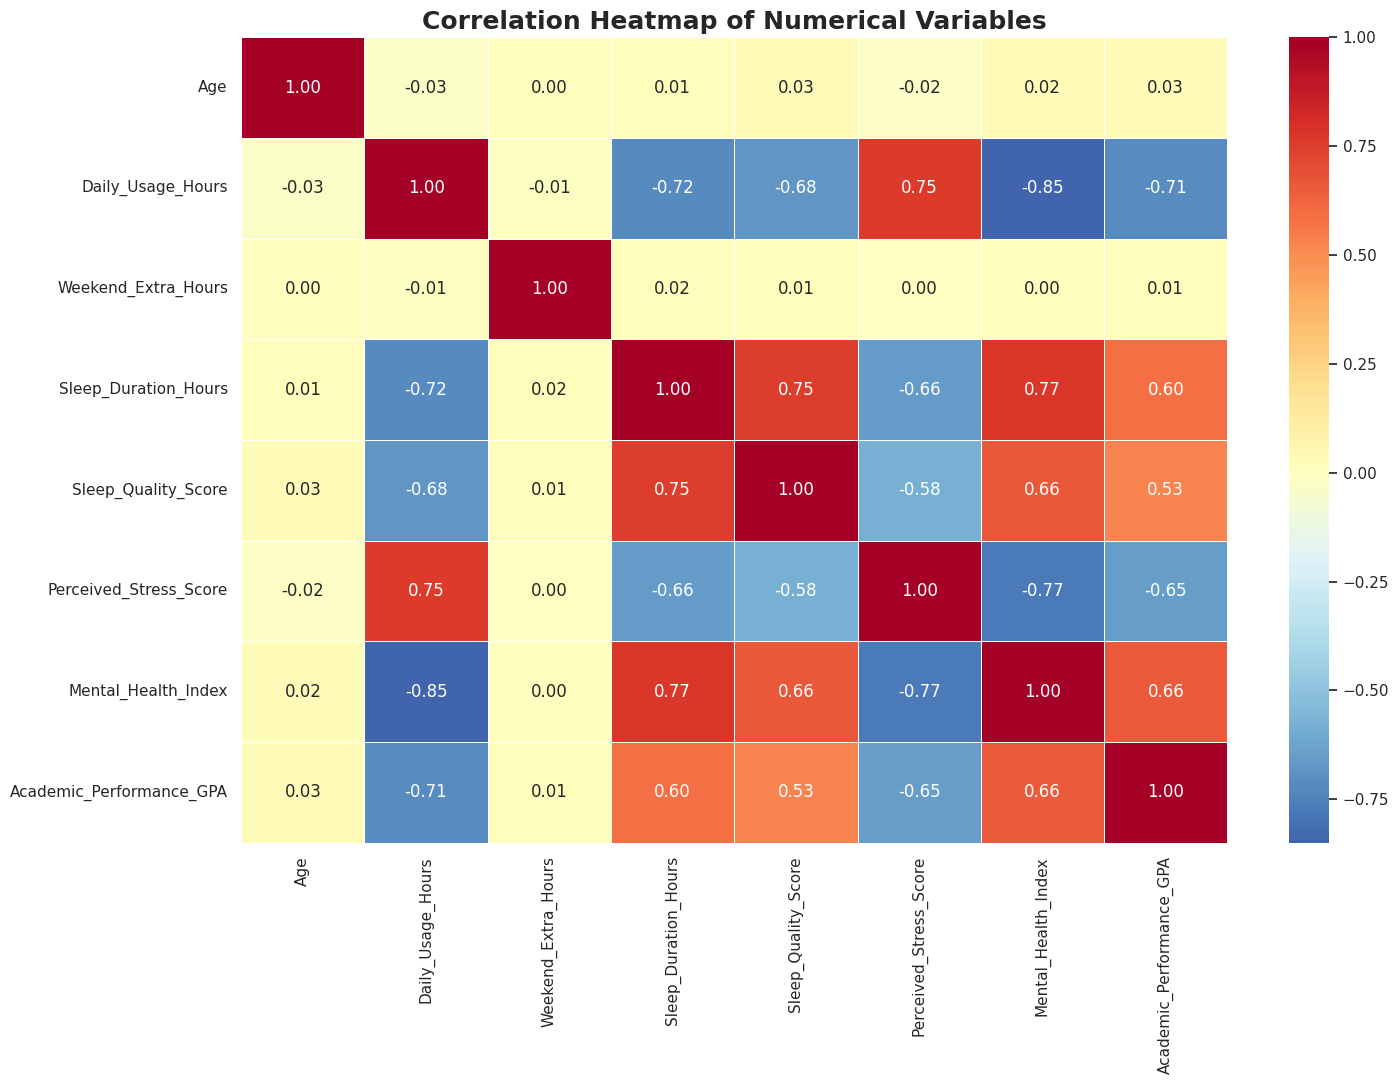


CORRELATION WITH ACADEMIC PERFORMANCE GPA
Academic_Performance_GPA    1.000000
Mental_Health_Index         0.659419
Sleep_Duration_Hours        0.595263
Sleep_Quality_Score         0.529270
Age                         0.028110
Weekend_Extra_Hours         0.012275
Perceived_Stress_Score     -0.650921
Daily_Usage_Hours          -0.710057
Name: Academic_Performance_GPA, dtype: float64


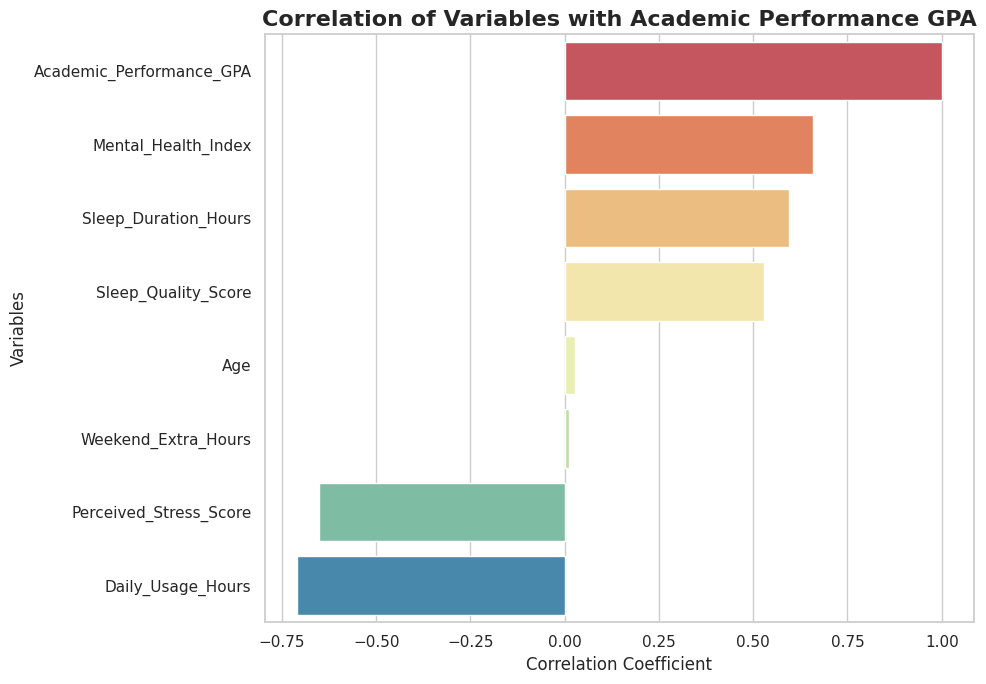


CORRELATION WITH MENTAL HEALTH INDEX
Mental_Health_Index         1.000000
Sleep_Duration_Hours        0.774220
Sleep_Quality_Score         0.662423
Academic_Performance_GPA    0.659419
Age                         0.022555
Weekend_Extra_Hours         0.004026
Perceived_Stress_Score     -0.773744
Daily_Usage_Hours          -0.849908
Name: Mental_Health_Index, dtype: float64


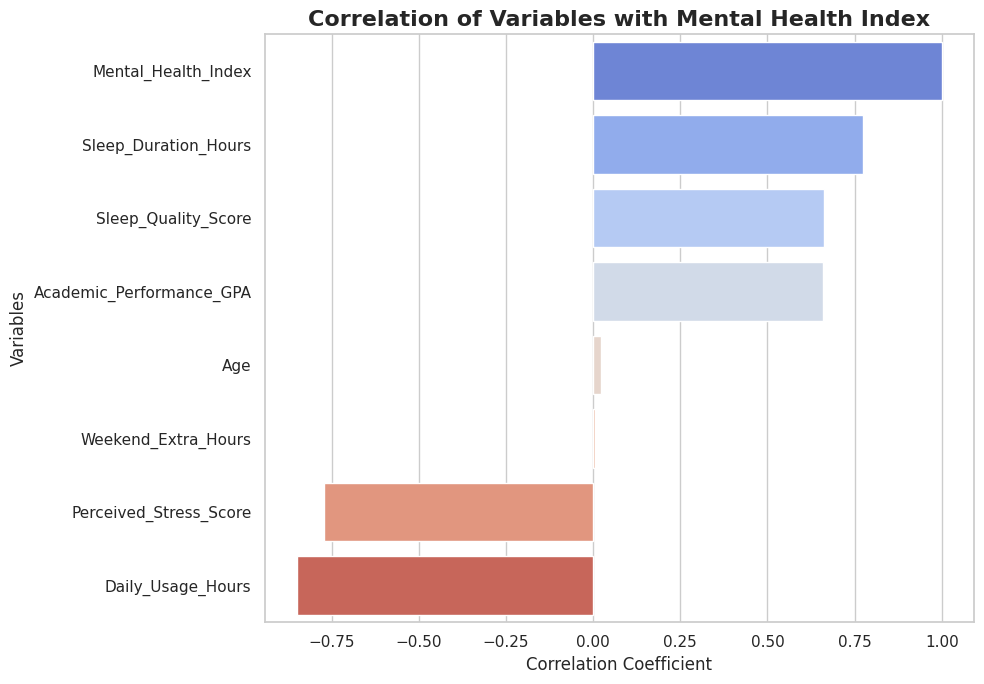

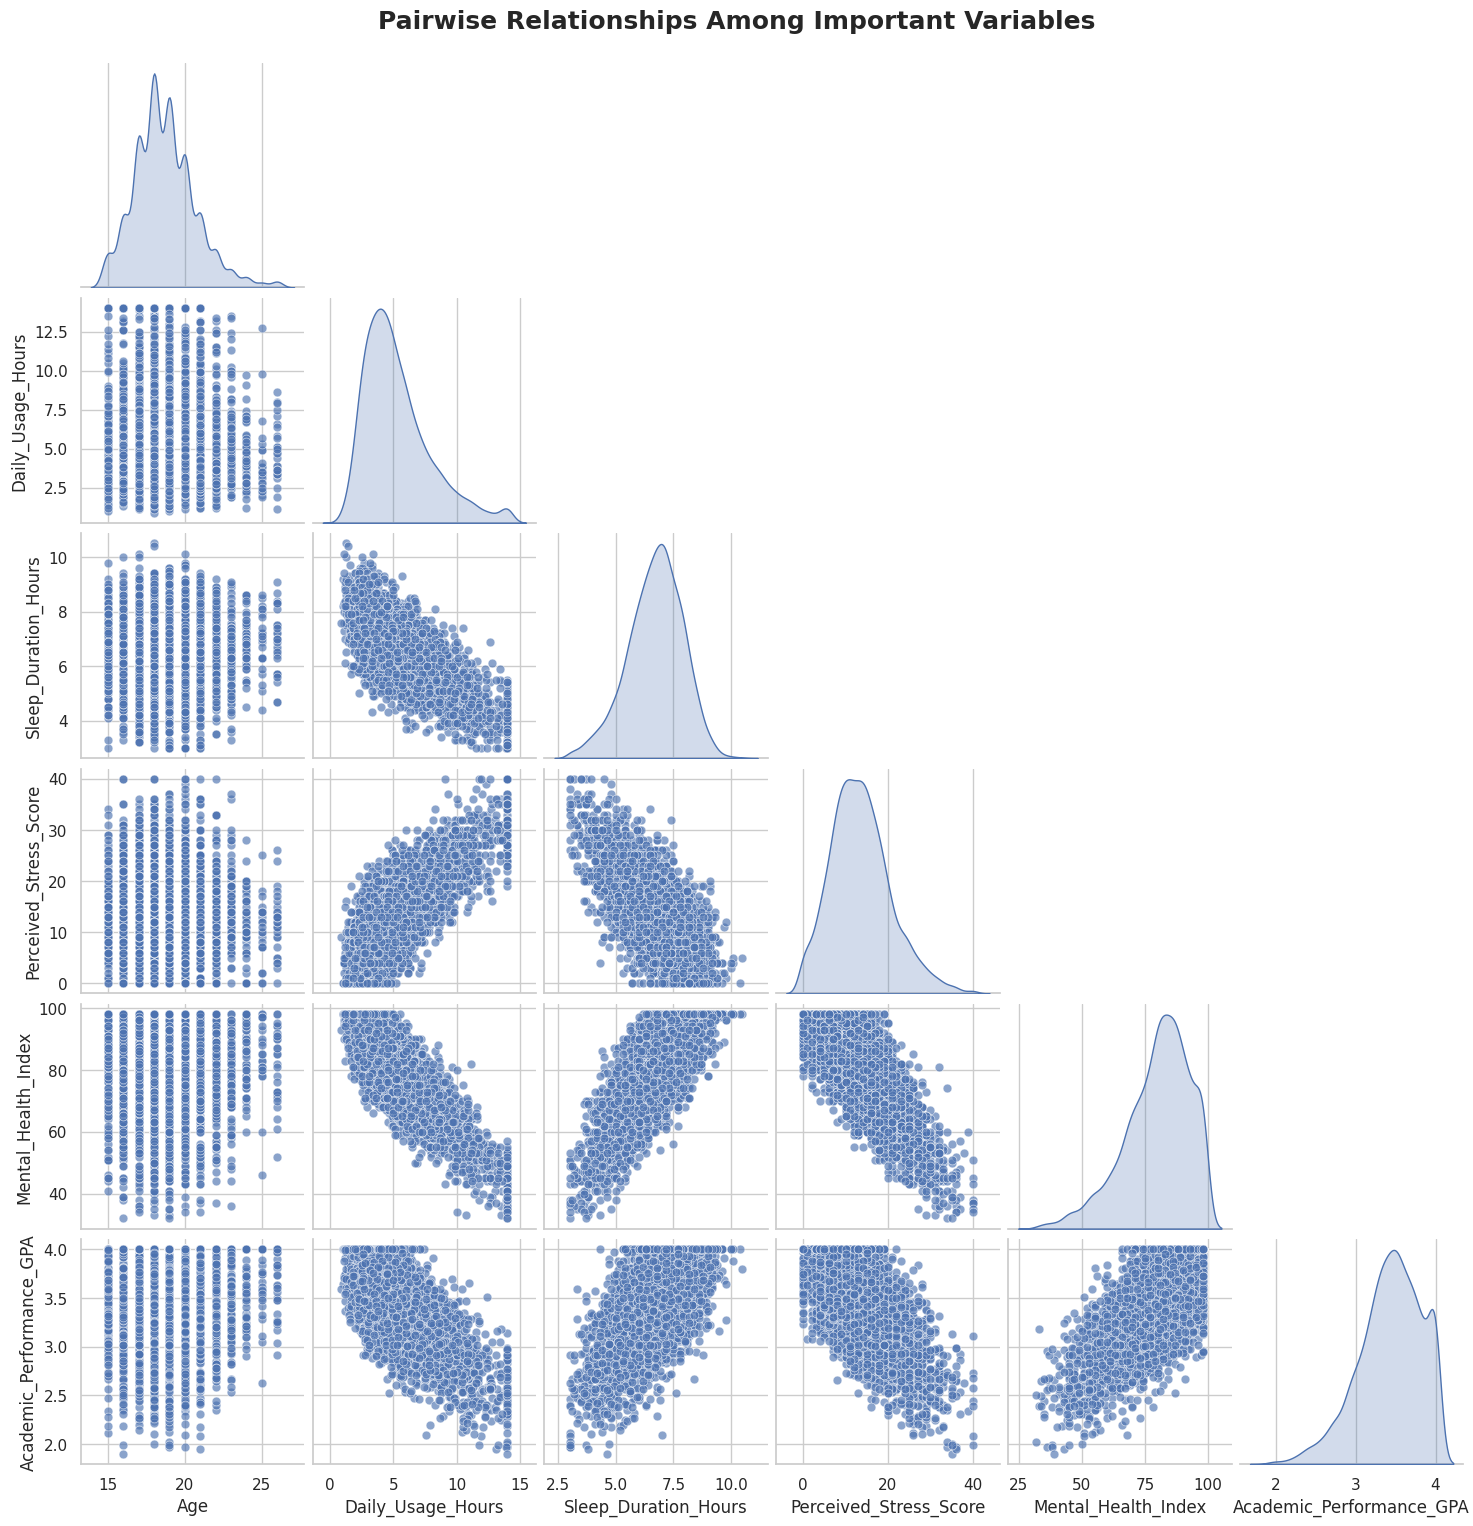

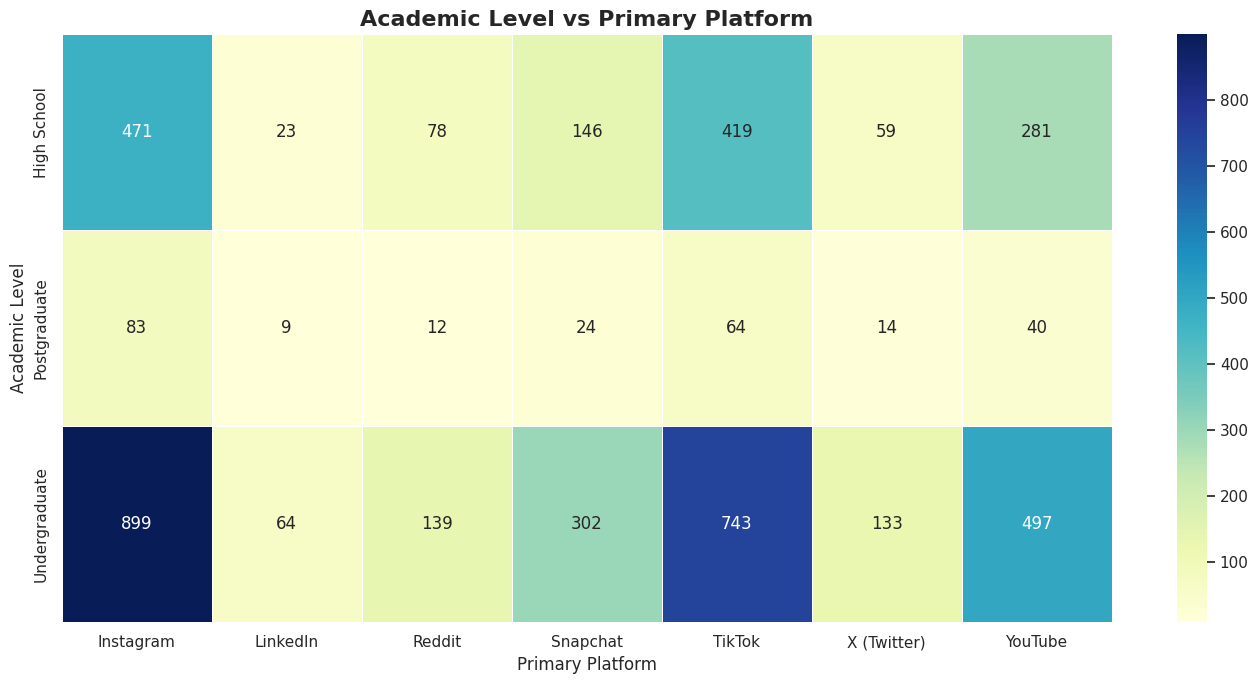

<Figure size 1400x700 with 0 Axes>

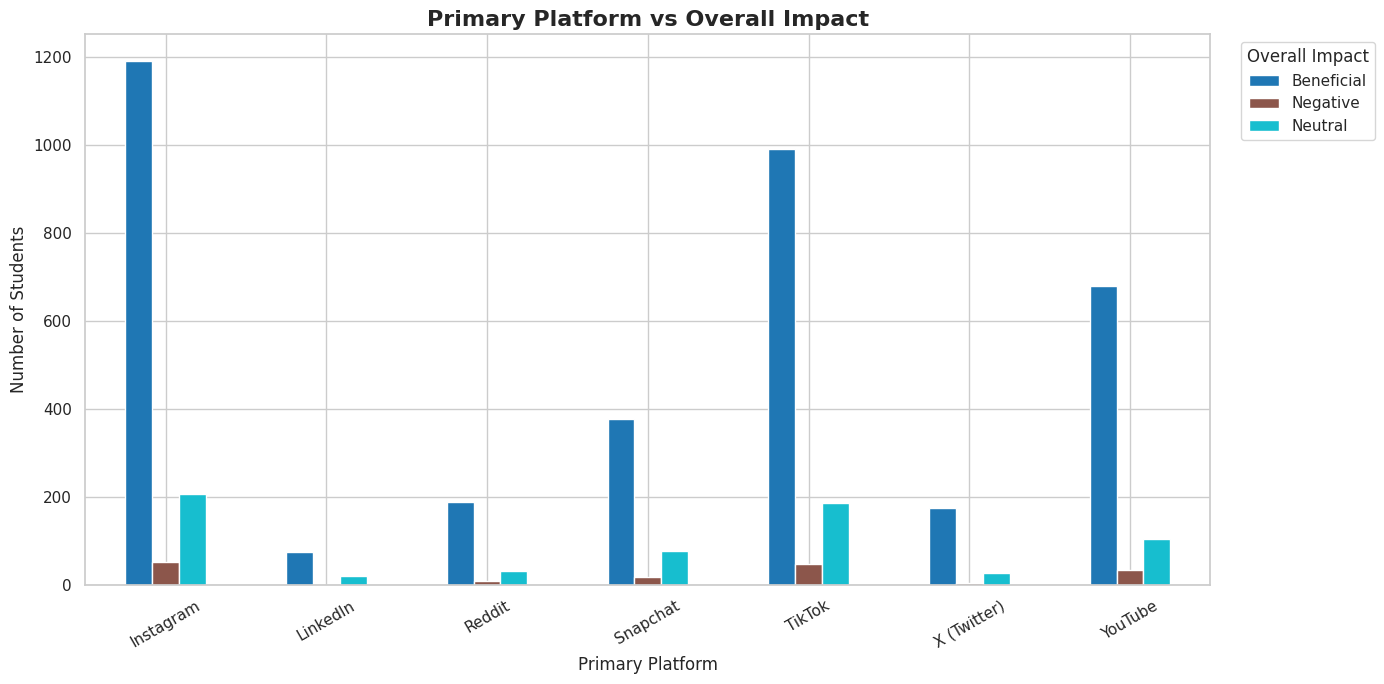

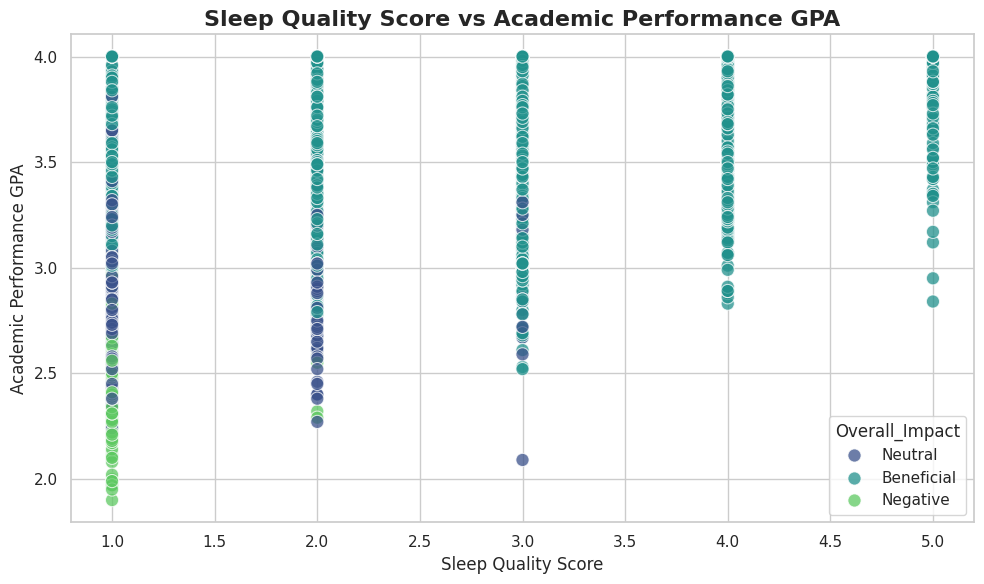

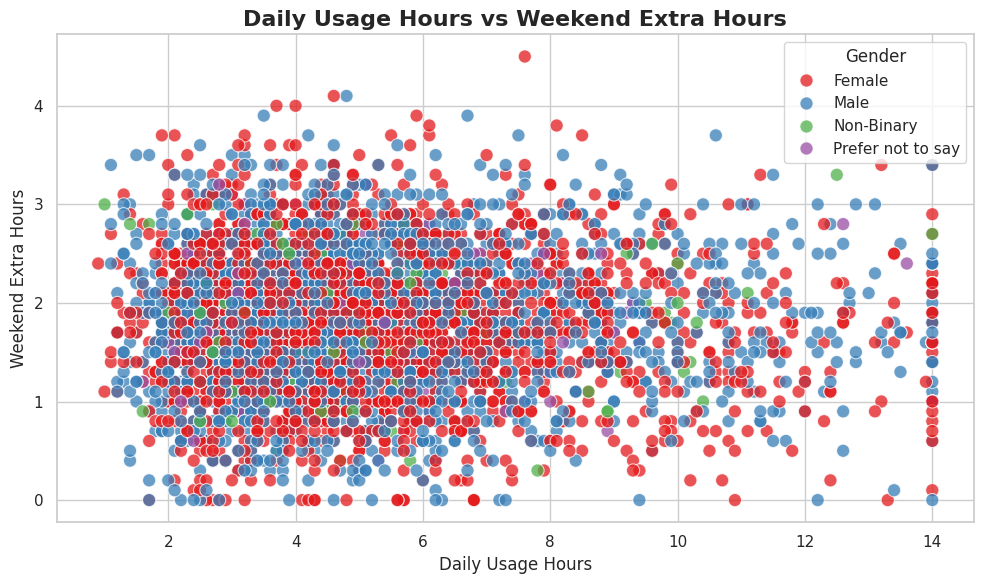

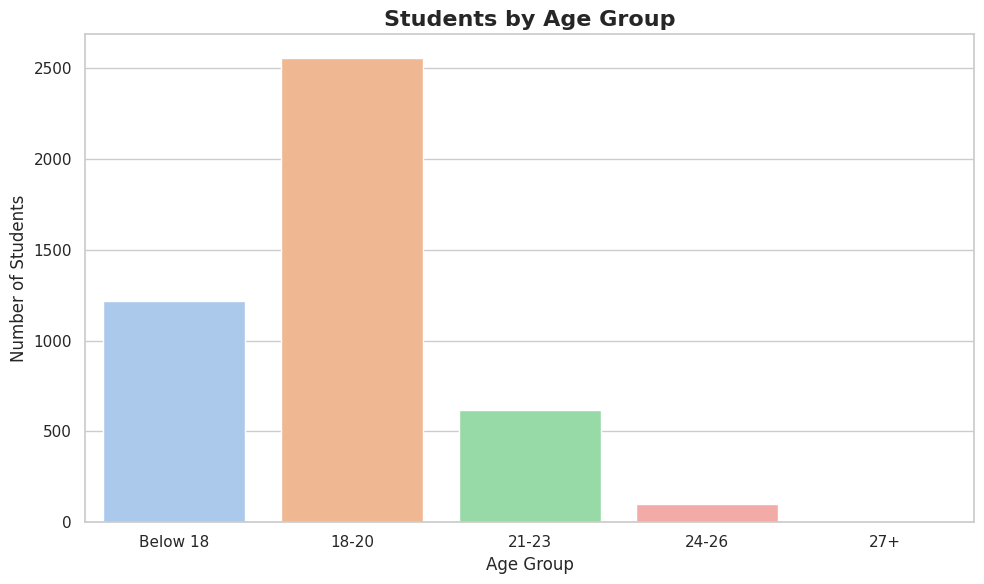

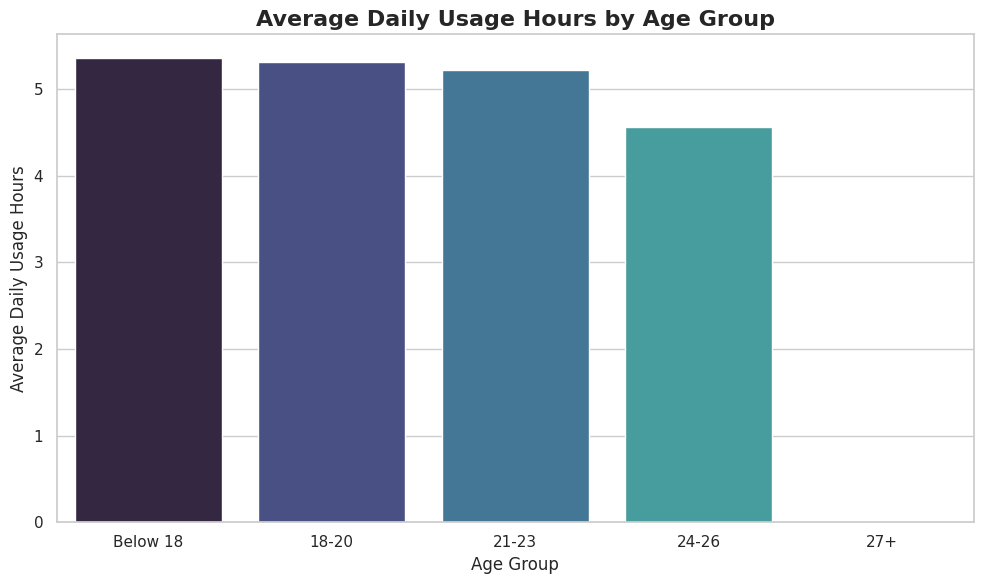

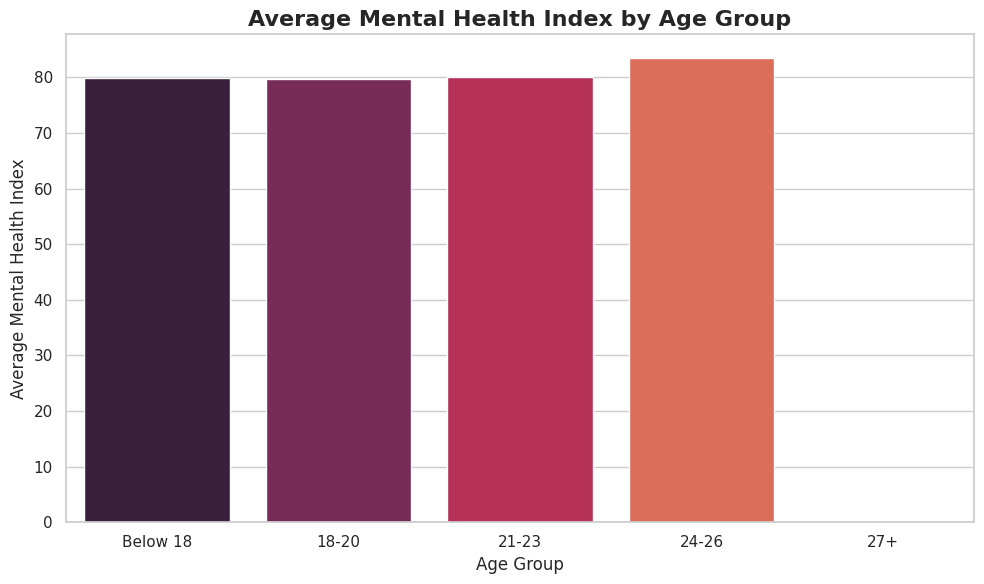


FINAL DATASET SUMMARY
Number of Rows: 4500
Number of Columns: 17

Numeric Columns:
['Age', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Perceived_Stress_Score', 'Mental_Health_Index', 'Academic_Performance_GPA']

Categorical Columns:
['Student_ID', 'Gender', 'Academic_Level', 'Primary_Platform', 'Device_Type', 'Social_Comparison_Frequency', 'Overall_Impact']

Missing Values:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
Age_Group                     

In [13]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Seaborn theme
sns.set_theme(style="whitegrid")

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(df.shape)

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
print(df.columns)

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
print(df.head())

# -----------------------------
# 3. BASIC INFORMATION
# -----------------------------
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(df.info())

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
print(df.describe(include="all").T)

# -----------------------------
# 4. CHECK MISSING VALUES
# -----------------------------
print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print(missing_values)

# Visualization of missing values
if len(missing_values) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_values.values,
        y=missing_values.index,
        palette="viridis"
    )

    plt.title("Missing Values by Column", fontsize=16, fontweight="bold")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Columns")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")

# ============================================================
# 5. DATA TYPE SEPARATION
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# ============================================================
# 6. GENDER DISTRIBUTION
# ============================================================

if "Gender" in df.columns:

    plt.figure(figsize=(8, 6))

    gender_counts = df["Gender"].value_counts()

    plt.pie(
        gender_counts.values,
        labels=gender_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", len(gender_counts))
    )

    plt.title("Gender Distribution", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ============================================================
# 7. ACADEMIC LEVEL DISTRIBUTION
# ============================================================

if "Academic_Level" in df.columns:

    plt.figure(figsize=(10, 6))

    order = df["Academic_Level"].value_counts().index

    sns.countplot(
        data=df,
        y="Academic_Level",
        order=order,
        palette="cool"
    )

    plt.title(
        "Distribution of Students by Academic Level",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Number of Students")
    plt.ylabel("Academic Level")
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. PRIMARY PLATFORM DISTRIBUTION
# ============================================================

if "Primary_Platform" in df.columns:

    platform_counts = df["Primary_Platform"].value_counts()

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=platform_counts.index,
        y=platform_counts.values,
        palette="rainbow"
    )

    plt.title(
        "Primary Social Media Platform Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 9. DEVICE TYPE DISTRIBUTION
# ============================================================

if "Device_Type" in df.columns:

    device_counts = df["Device_Type"].value_counts()

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=device_counts.index,
        y=device_counts.values,
        palette="Set1"
    )

    plt.title(
        "Device Type Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Device Type")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# ============================================================
# 10. AGE DISTRIBUTION
# ============================================================

if "Age" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Age",
        bins=15,
        kde=True,
        color="royalblue"
    )

    plt.title(
        "Age Distribution of Students",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 11. DAILY USAGE HOURS
# ============================================================

if "Daily_Usage_Hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Daily_Usage_Hours",
        bins=20,
        kde=True,
        color="darkorange"
    )

    plt.title(
        "Distribution of Daily Usage Hours",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Daily Usage Hours")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 12. WEEKEND EXTRA HOURS
# ============================================================

if "Weekend_Extra_Hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Weekend_Extra_Hours",
        bins=20,
        kde=True,
        color="mediumseagreen"
    )

    plt.title(
        "Weekend Extra Usage Hours",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Weekend Extra Hours")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 13. SLEEP DURATION
# ============================================================

if "Sleep_Duration_Hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Sleep_Duration_Hours",
        bins=20,
        kde=True,
        color="purple"
    )

    plt.title(
        "Distribution of Sleep Duration",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Sleep Duration (Hours)")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 14. SLEEP QUALITY SCORE
# ============================================================

if "Sleep_Quality_Score" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Sleep_Quality_Score",
        bins=15,
        kde=True,
        color="teal"
    )

    plt.title(
        "Sleep Quality Score Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Sleep Quality Score")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 15. LATE NIGHT USAGE
# ============================================================

if "Late_Night_Usage" in df.columns:

    plt.figure(figsize=(9, 6))

    late_counts = df["Late_Night_Usage"].value_counts()

    sns.barplot(
        x=late_counts.index,
        y=late_counts.values,
        palette="magma"
    )

    plt.title(
        "Late Night Usage Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Late Night Usage")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# ============================================================
# 16. SOCIAL COMPARISON FREQUENCY
# ============================================================

if "Social_Comparison_Frequency" in df.columns:

    plt.figure(figsize=(10, 6))

    comparison_counts = df[
        "Social_Comparison_Frequency"
    ].value_counts()

    sns.barplot(
        x=comparison_counts.index,
        y=comparison_counts.values,
        palette="plasma"
    )

    plt.title(
        "Social Comparison Frequency",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Social Comparison Frequency")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 17. PERCEIVED STRESS SCORE
# ============================================================

if "Perceived_Stress_Score" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Perceived_Stress_Score",
        bins=20,
        kde=True,
        color="crimson"
    )

    plt.title(
        "Perceived Stress Score Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Perceived Stress Score")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 18. MENTAL HEALTH INDEX
# ============================================================

if "Mental_Health_Index" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Mental_Health_Index",
        bins=20,
        kde=True,
        color="hotpink"
    )

    plt.title(
        "Mental Health Index Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Mental Health Index")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 19. ACADEMIC PERFORMANCE GPA
# ============================================================

if "Academic_Performance_GPA" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="Academic_Performance_GPA",
        bins=20,
        kde=True,
        color="dodgerblue"
    )

    plt.title(
        "Academic Performance GPA Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Academic Performance GPA")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 20. OVERALL IMPACT DISTRIBUTION
# ============================================================

if "Overall_Impact" in df.columns:

    plt.figure(figsize=(10, 6))

    impact_counts = df["Overall_Impact"].value_counts()

    sns.barplot(
        x=impact_counts.index,
        y=impact_counts.values,
        palette="Spectral"
    )

    plt.title(
        "Overall Impact Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Overall Impact")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 21. DAILY USAGE VS GPA
# ============================================================

if "Daily_Usage_Hours" in df.columns and \
   "Academic_Performance_GPA" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Daily_Usage_Hours",
        y="Academic_Performance_GPA",
        hue="Gender" if "Gender" in df.columns else None,
        palette="Set1",
        s=90,
        alpha=0.75
    )

    plt.title(
        "Daily Usage Hours vs Academic Performance GPA",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Daily Usage Hours")
    plt.ylabel("Academic Performance GPA")

    plt.tight_layout()
    plt.show()

# ============================================================
# 22. DAILY USAGE VS SLEEP DURATION
# ============================================================

if "Daily_Usage_Hours" in df.columns and \
   "Sleep_Duration_Hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Daily_Usage_Hours",
        y="Sleep_Duration_Hours",
        hue="Gender" if "Gender" in df.columns else None,
        palette="Dark2",
        s=90,
        alpha=0.75
    )

    plt.title(
        "Daily Usage Hours vs Sleep Duration",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Daily Usage Hours")
    plt.ylabel("Sleep Duration (Hours)")

    plt.tight_layout()
    plt.show()

# ============================================================
# 23. DAILY USAGE VS STRESS
# ============================================================

if "Daily_Usage_Hours" in df.columns and \
   "Perceived_Stress_Score" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.regplot(
        data=df,
        x="Daily_Usage_Hours",
        y="Perceived_Stress_Score",
        scatter_kws={"alpha": 0.6, "s": 70},
        line_kws={"linewidth": 2},
        color="red"
    )

    plt.title(
        "Daily Usage Hours vs Perceived Stress",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Daily Usage Hours")
    plt.ylabel("Perceived Stress Score")

    plt.tight_layout()
    plt.show()

# ============================================================
# 24. SLEEP VS MENTAL HEALTH
# ============================================================

if "Sleep_Duration_Hours" in df.columns and \
   "Mental_Health_Index" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Sleep_Duration_Hours",
        y="Mental_Health_Index",
        hue="Academic_Level" if "Academic_Level" in df.columns else None,
        palette="viridis",
        s=90,
        alpha=0.75
    )

    plt.title(
        "Sleep Duration vs Mental Health Index",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Sleep Duration (Hours)")
    plt.ylabel("Mental Health Index")

    plt.tight_layout()
    plt.show()

# ============================================================
# 25. STRESS VS GPA
# ============================================================

if "Perceived_Stress_Score" in df.columns and \
   "Academic_Performance_GPA" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.regplot(
        data=df,
        x="Perceived_Stress_Score",
        y="Academic_Performance_GPA",
        scatter_kws={"alpha": 0.6, "s": 70},
        line_kws={"linewidth": 2},
        color="darkviolet"
    )

    plt.title(
        "Perceived Stress Score vs Academic Performance GPA",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Perceived Stress Score")
    plt.ylabel("Academic Performance GPA")

    plt.tight_layout()
    plt.show()

# ============================================================
# 26. BOXPLOT - DAILY USAGE BY GENDER
# ============================================================

if "Daily_Usage_Hours" in df.columns and \
   "Gender" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Gender",
        y="Daily_Usage_Hours",
        palette="Set3"
    )

    plt.title(
        "Daily Usage Hours by Gender",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Gender")
    plt.ylabel("Daily Usage Hours")

    plt.tight_layout()
    plt.show()

# ============================================================
# 27. BOXPLOT - GPA BY ACADEMIC LEVEL
# ============================================================

if "Academic_Performance_GPA" in df.columns and \
   "Academic_Level" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.boxplot(
        data=df,
        x="Academic_Level",
        y="Academic_Performance_GPA",
        palette="Set2"
    )

    plt.title(
        "GPA Distribution by Academic Level",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Academic Level")
    plt.ylabel("Academic Performance GPA")

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# ============================================================
# 28. BOXPLOT - STRESS BY OVERALL IMPACT
# ============================================================

if "Perceived_Stress_Score" in df.columns and \
   "Overall_Impact" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.boxplot(
        data=df,
        x="Overall_Impact",
        y="Perceived_Stress_Score",
        palette="coolwarm"
    )

    plt.title(
        "Perceived Stress by Overall Impact",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Overall Impact")
    plt.ylabel("Perceived Stress Score")

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# ============================================================
# 29. AVERAGE DAILY USAGE BY PLATFORM
# ============================================================

if "Primary_Platform" in df.columns and \
   "Daily_Usage_Hours" in df.columns:

    platform_usage = (
        df.groupby("Primary_Platform")["Daily_Usage_Hours"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=platform_usage.index,
        y=platform_usage.values,
        palette="husl"
    )

    plt.title(
        "Average Daily Usage Hours by Primary Platform",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Average Daily Usage Hours")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 30. AVERAGE GPA BY PLATFORM
# ============================================================

if "Primary_Platform" in df.columns and \
   "Academic_Performance_GPA" in df.columns:

    platform_gpa = (
        df.groupby("Primary_Platform")["Academic_Performance_GPA"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=platform_gpa.index,
        y=platform_gpa.values,
        palette="cubehelix"
    )

    plt.title(
        "Average GPA by Primary Platform",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Average GPA")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 31. AVERAGE SLEEP BY PLATFORM
# ============================================================

if "Primary_Platform" in df.columns and \
   "Sleep_Duration_Hours" in df.columns:

    platform_sleep = (
        df.groupby("Primary_Platform")["Sleep_Duration_Hours"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=platform_sleep.index,
        y=platform_sleep.values,
        palette="rocket"
    )

    plt.title(
        "Average Sleep Duration by Primary Platform",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Average Sleep Duration (Hours)")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# 32. AVERAGE STRESS BY ACADEMIC LEVEL
# ============================================================

if "Academic_Level" in df.columns and \
   "Perceived_Stress_Score" in df.columns:

    academic_stress = (
        df.groupby("Academic_Level")["Perceived_Stress_Score"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=academic_stress.index,
        y=academic_stress.values,
        palette="flare"
    )

    plt.title(
        "Average Perceived Stress by Academic Level",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Academic Level")
    plt.ylabel("Average Stress Score")

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# ============================================================
# 33. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:

    correlation = numeric_df.corr()

    plt.figure(figsize=(15, 11))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="RdYlBu_r",
        linewidths=0.5,
        center=0
    )

    plt.title(
        "Correlation Heatmap of Numerical Variables",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 34. CORRELATION WITH GPA
# ============================================================

if "Academic_Performance_GPA" in numeric_df.columns:

    gpa_corr = (
        numeric_df.corr()["Academic_Performance_GPA"]
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 70)
    print("CORRELATION WITH ACADEMIC PERFORMANCE GPA")
    print("=" * 70)
    print(gpa_corr)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        x=gpa_corr.values,
        y=gpa_corr.index,
        palette="Spectral"
    )

    plt.title(
        "Correlation of Variables with Academic Performance GPA",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Correlation Coefficient")
    plt.ylabel("Variables")

    plt.tight_layout()
    plt.show()

# ============================================================
# 35. CORRELATION WITH MENTAL HEALTH INDEX
# ============================================================

if "Mental_Health_Index" in numeric_df.columns:

    mental_corr = (
        numeric_df.corr()["Mental_Health_Index"]
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 70)
    print("CORRELATION WITH MENTAL HEALTH INDEX")
    print("=" * 70)
    print(mental_corr)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        x=mental_corr.values,
        y=mental_corr.index,
        palette="coolwarm"
    )

    plt.title(
        "Correlation of Variables with Mental Health Index",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Correlation Coefficient")
    plt.ylabel("Variables")

    plt.tight_layout()
    plt.show()

# ============================================================
# 36. PAIRPLOT
# ============================================================

pair_columns = [
    "Age",
    "Daily_Usage_Hours",
    "Sleep_Duration_Hours",
    "Perceived_Stress_Score",
    "Mental_Health_Index",
    "Academic_Performance_GPA"
]

pair_columns = [
    col for col in pair_columns
    if col in df.columns
]

if len(pair_columns) >= 3:

    sns.pairplot(
        df[pair_columns].dropna(),
        diag_kind="kde",
        corner=True,
        plot_kws={
            "alpha": 0.65,
            "s": 40
        }
    )

    plt.suptitle(
        "Pairwise Relationships Among Important Variables",
        y=1.02,
        fontsize=18,
        fontweight="bold"
    )

    plt.show()

# ============================================================
# 37. MULTIVARIATE HEATMAP - ACADEMIC LEVEL VS PLATFORM
# ============================================================

if "Academic_Level" in df.columns and \
   "Primary_Platform" in df.columns:

    cross_table = pd.crosstab(
        df["Academic_Level"],
        df["Primary_Platform"]
    )

    plt.figure(figsize=(14, 7))

    sns.heatmap(
        cross_table,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.5
    )

    plt.title(
        "Academic Level vs Primary Platform",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Academic Level")

    plt.tight_layout()
    plt.show()

# ============================================================
# 38. PLATFORM VS OVERALL IMPACT
# ============================================================

if "Primary_Platform" in df.columns and \
   "Overall_Impact" in df.columns:

    platform_impact = pd.crosstab(
        df["Primary_Platform"],
        df["Overall_Impact"]
    )

    plt.figure(figsize=(14, 7))

    platform_impact.plot(
        kind="bar",
        figsize=(14, 7),
        colormap="tab10"
    )

    plt.title(
        "Primary Platform vs Overall Impact",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Primary Platform")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)
    plt.legend(
        title="Overall Impact",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 39. SLEEP QUALITY VS GPA
# ============================================================

if "Sleep_Quality_Score" in df.columns and \
   "Academic_Performance_GPA" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Sleep_Quality_Score",
        y="Academic_Performance_GPA",
        hue="Overall_Impact" if "Overall_Impact" in df.columns else None,
        palette="viridis",
        s=90,
        alpha=0.75
    )

    plt.title(
        "Sleep Quality Score vs Academic Performance GPA",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Sleep Quality Score")
    plt.ylabel("Academic Performance GPA")

    plt.tight_layout()
    plt.show()

# ============================================================
# 40. WEEKEND EXTRA HOURS VS DAILY USAGE
# ============================================================

if "Weekend_Extra_Hours" in df.columns and \
   "Daily_Usage_Hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x="Daily_Usage_Hours",
        y="Weekend_Extra_Hours",
        hue="Gender" if "Gender" in df.columns else None,
        palette="Set1",
        s=90,
        alpha=0.75
    )

    plt.title(
        "Daily Usage Hours vs Weekend Extra Hours",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Daily Usage Hours")
    plt.ylabel("Weekend Extra Hours")

    plt.tight_layout()
    plt.show()

# ============================================================
# 41. AGE GROUP CREATION
# ============================================================

if "Age" in df.columns:

    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[0, 17, 20, 23, 26, 100],
        labels=[
            "Below 18",
            "18-20",
            "21-23",
            "24-26",
            "27+"
        ]
    )

    age_group_counts = df["Age_Group"].value_counts().sort_index()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=age_group_counts.index,
        y=age_group_counts.values,
        palette="pastel"
    )

    plt.title(
        "Students by Age Group",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

# ============================================================
# 42. AVERAGE USAGE BY AGE GROUP
# ============================================================

if "Age_Group" in df.columns and \
   "Daily_Usage_Hours" in df.columns:

    age_usage = (
        df.groupby("Age_Group", observed=True)["Daily_Usage_Hours"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=age_usage,
        x="Age_Group",
        y="Daily_Usage_Hours",
        palette="mako"
    )

    plt.title(
        "Average Daily Usage Hours by Age Group",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Average Daily Usage Hours")

    plt.tight_layout()
    plt.show()

# ============================================================
# 43. AVERAGE MENTAL HEALTH BY AGE GROUP
# ============================================================

if "Age_Group" in df.columns and \
   "Mental_Health_Index" in df.columns:

    age_mental = (
        df.groupby("Age_Group", observed=True)["Mental_Health_Index"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=age_mental,
        x="Age_Group",
        y="Mental_Health_Index",
        palette="rocket"
    )

    plt.title(
        "Average Mental Health Index by Age Group",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Average Mental Health Index")

    plt.tight_layout()
    plt.show()

# ============================================================
# 44. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nVisualization completed successfully.")

## Feature engineering

DATASET SHAPE
Rows    : 4500
Columns : 17

COLUMN NAMES
['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Primary_Platform', 'Daily_Usage_Hours', 'Weekend_Extra_Hours', 'Device_Type', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Late_Night_Usage', 'Social_Comparison_Frequency', 'Perceived_Stress_Score', 'Mental_Health_Index', 'Academic_Performance_GPA', 'Overall_Impact', 'Age_Group']

FIRST 5 ROWS
    Student_ID  Age  Gender Academic_Level Primary_Platform  \
0  STU_2024000   19  Female  Undergraduate         Snapchat   
1  STU_2024001   19  Female  Undergraduate        Instagram   
2  STU_2024002   17  Female    High School           TikTok   
3  STU_2024003   16  Female    High School          YouTube   
4  STU_2024004   17    Male    High School         LinkedIn   

   Daily_Usage_Hours  Weekend_Extra_Hours Device_Type  Sleep_Duration_Hours  \
0                7.5                  1.5  Smartphone                   5.9   
1                4.6                  1.3  Smartphone     

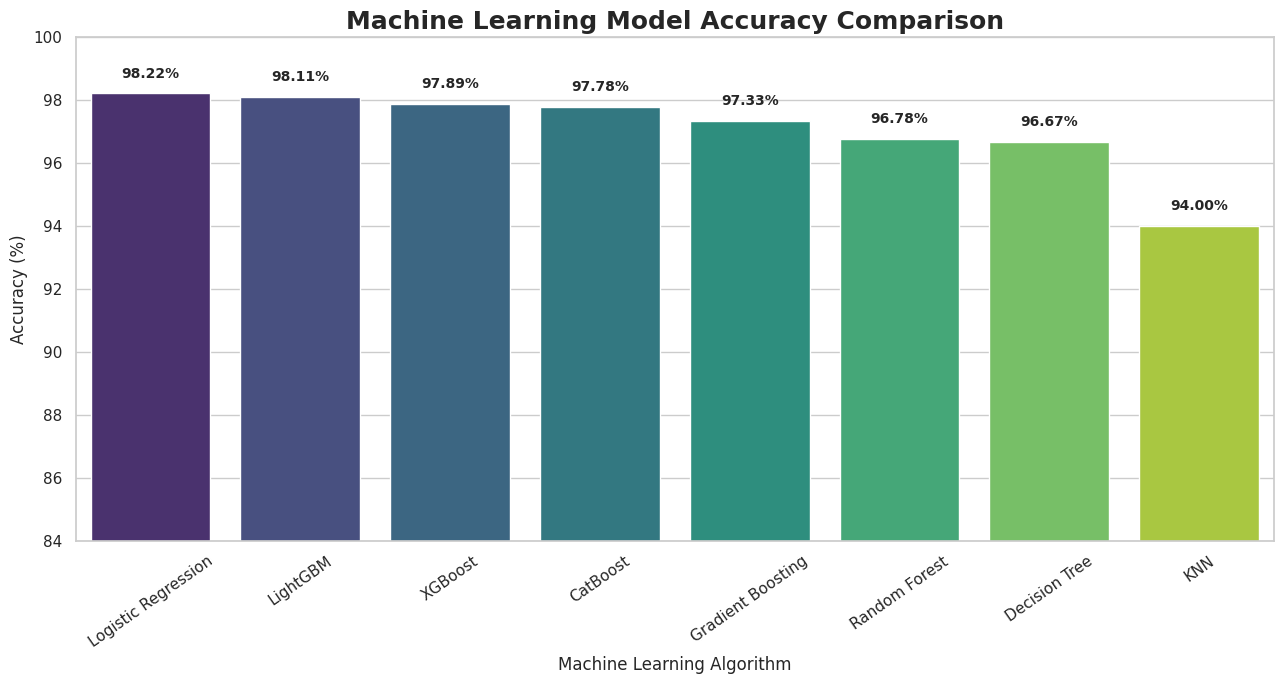

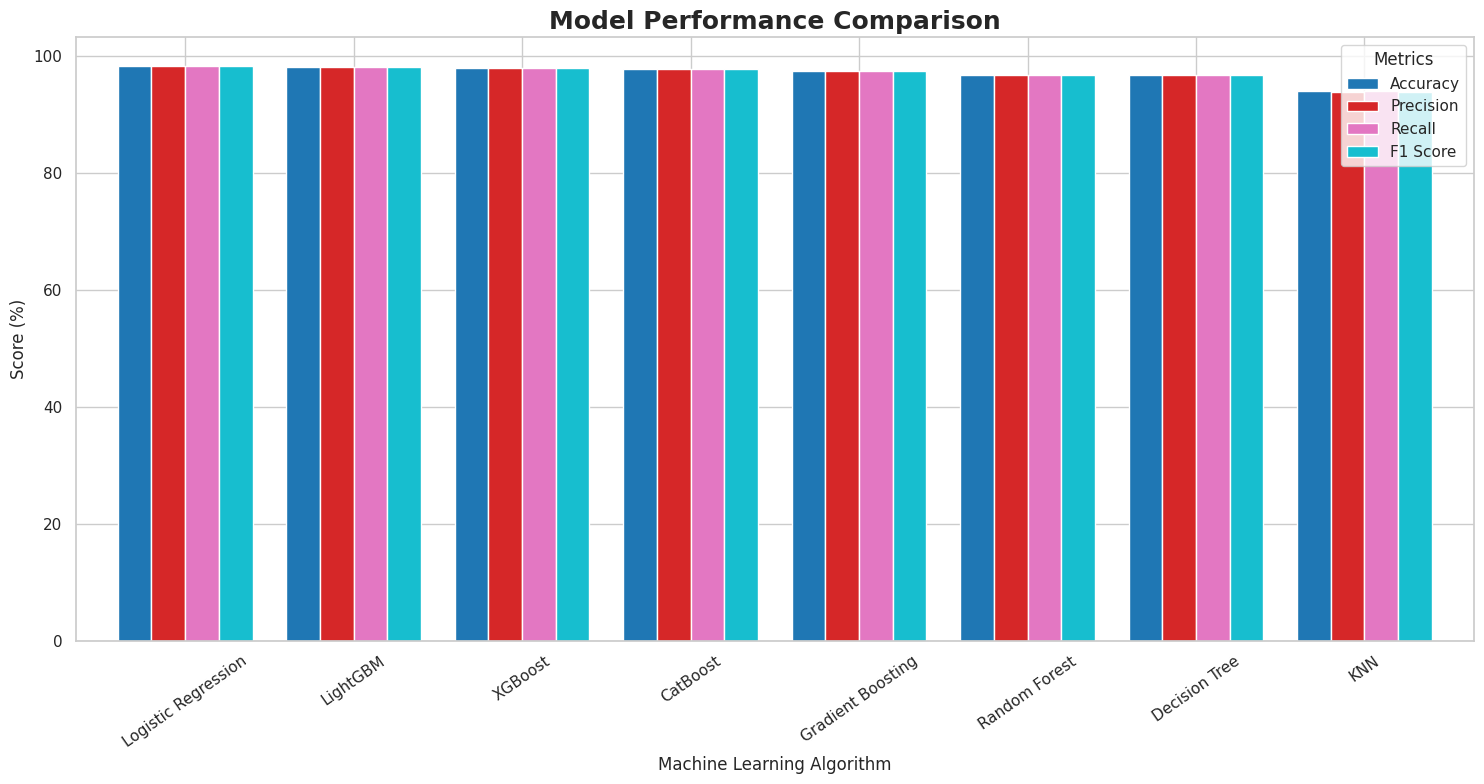

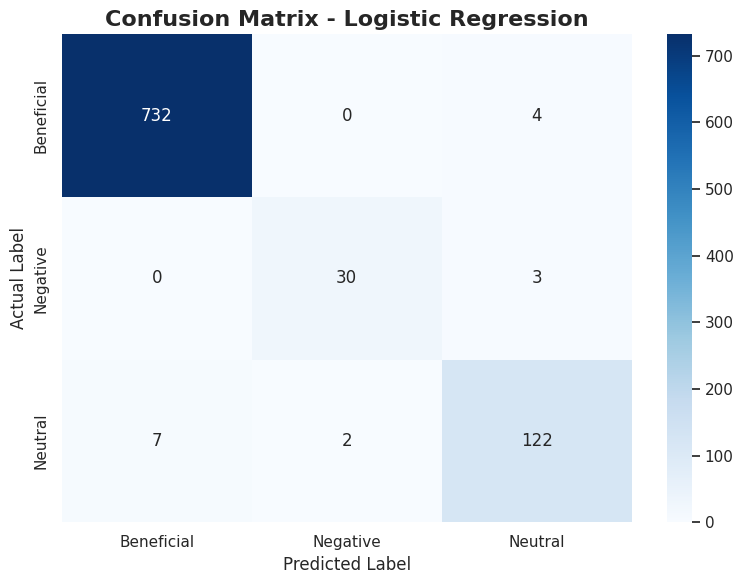

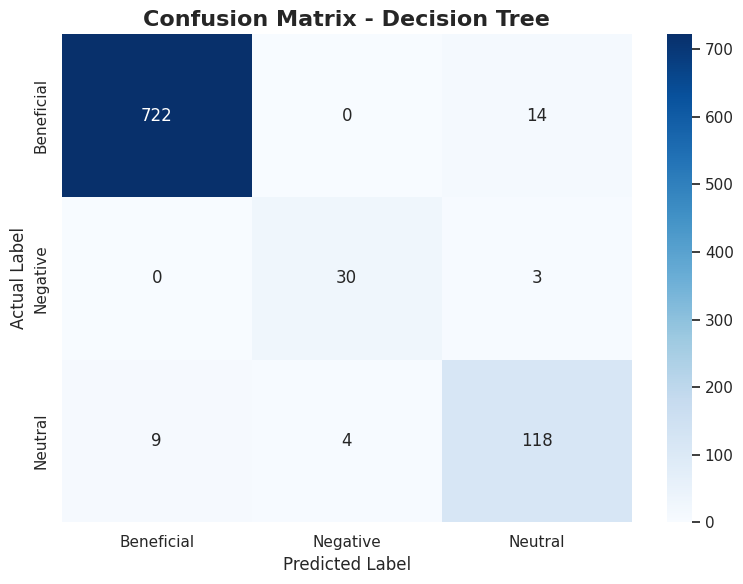

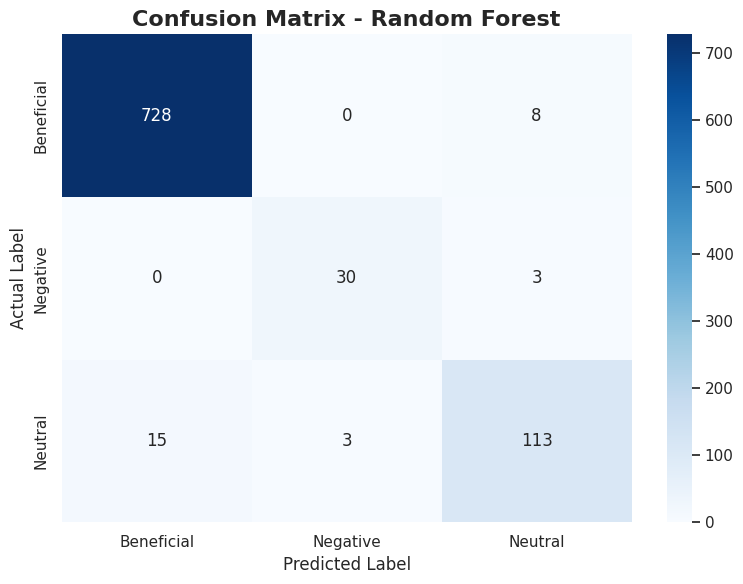

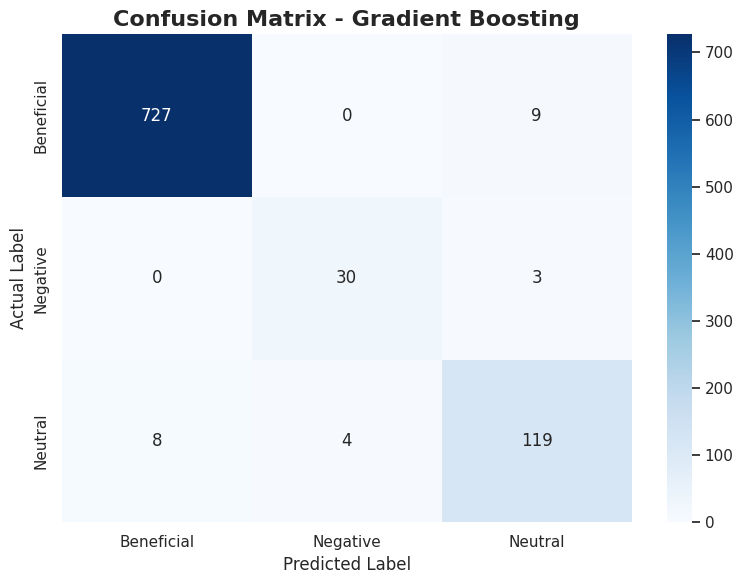

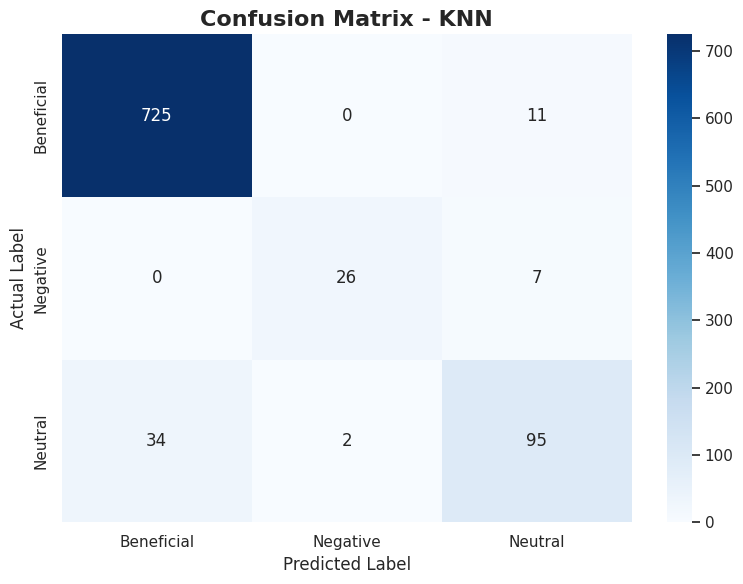

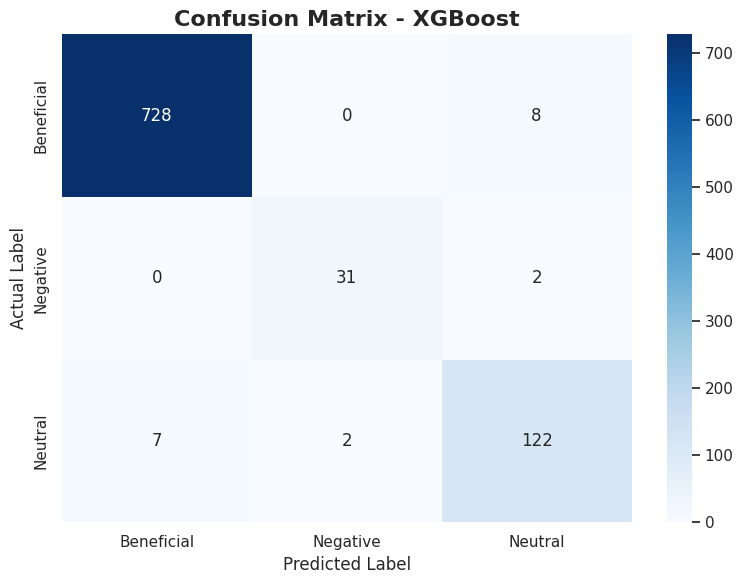

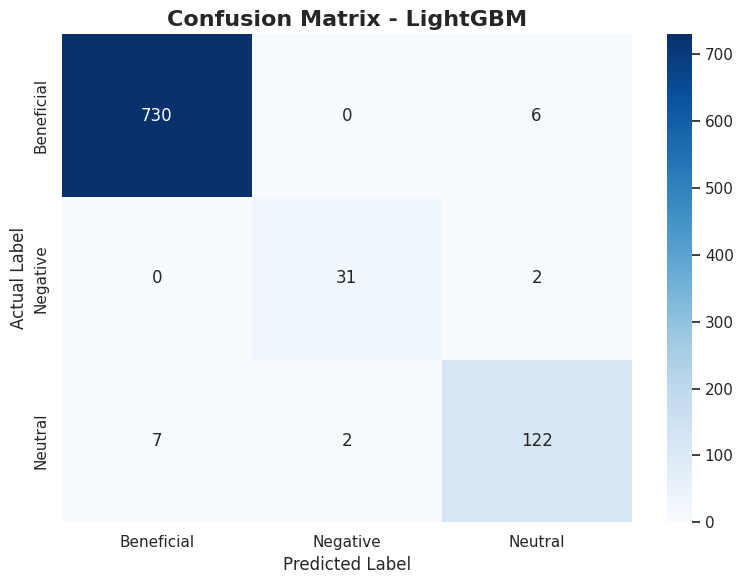

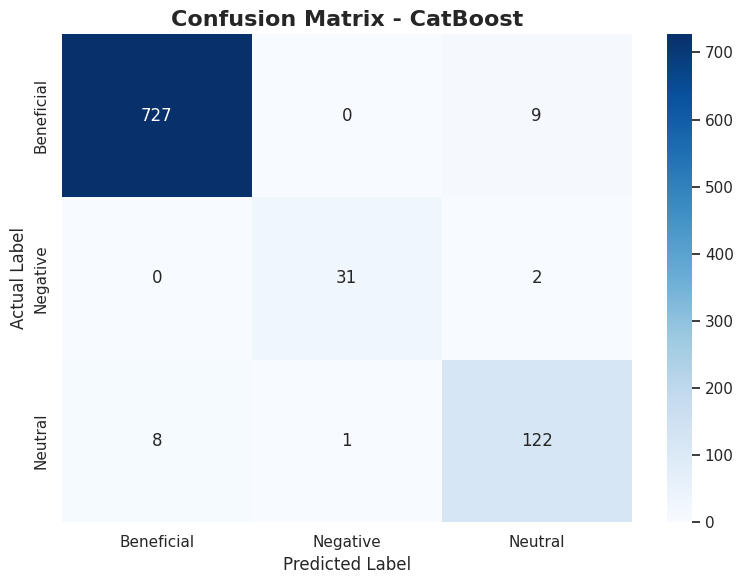


CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

  Beneficial       0.99      0.99      0.99       736
    Negative       0.94      0.91      0.92        33
     Neutral       0.95      0.93      0.94       131

    accuracy                           0.98       900
   macro avg       0.96      0.94      0.95       900
weighted avg       0.98      0.98      0.98       900


CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

  Beneficial       0.99      0.98      0.98       736
    Negative       0.88      0.91      0.90        33
     Neutral       0.87      0.90      0.89       131

    accuracy                           0.97       900
   macro avg       0.91      0.93      0.92       900
weighted avg       0.97      0.97      0.97       900


CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

  Beneficial       0.98      0.99      0.98       736
    Ne

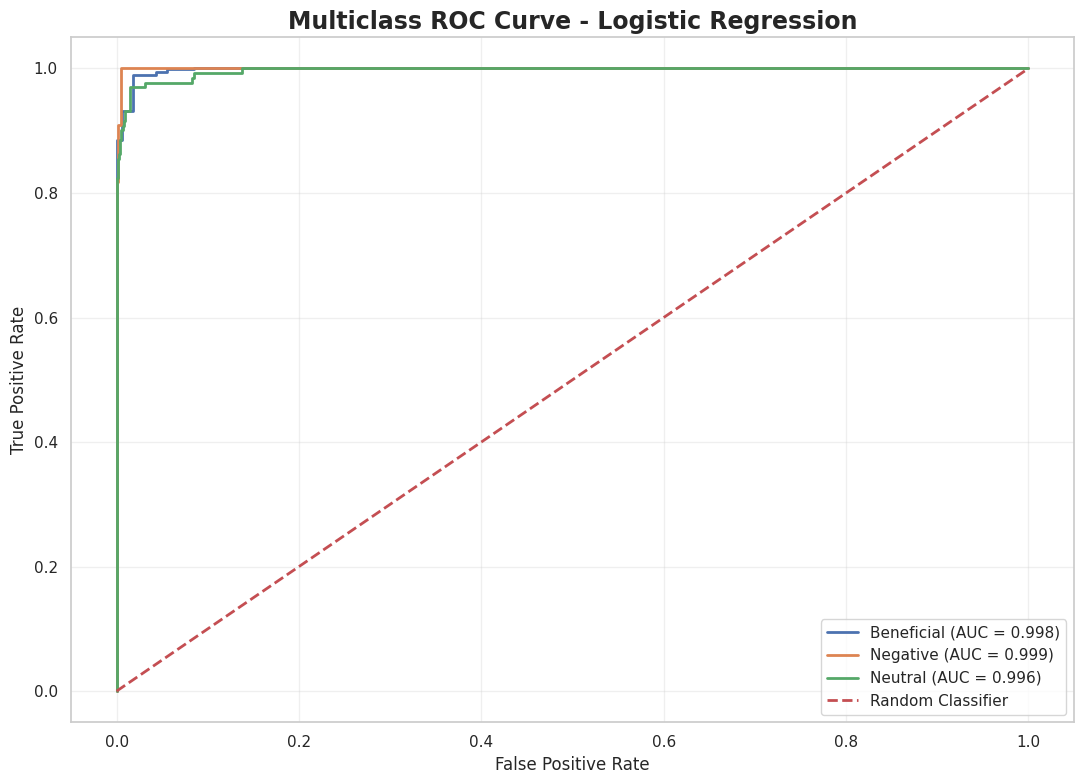

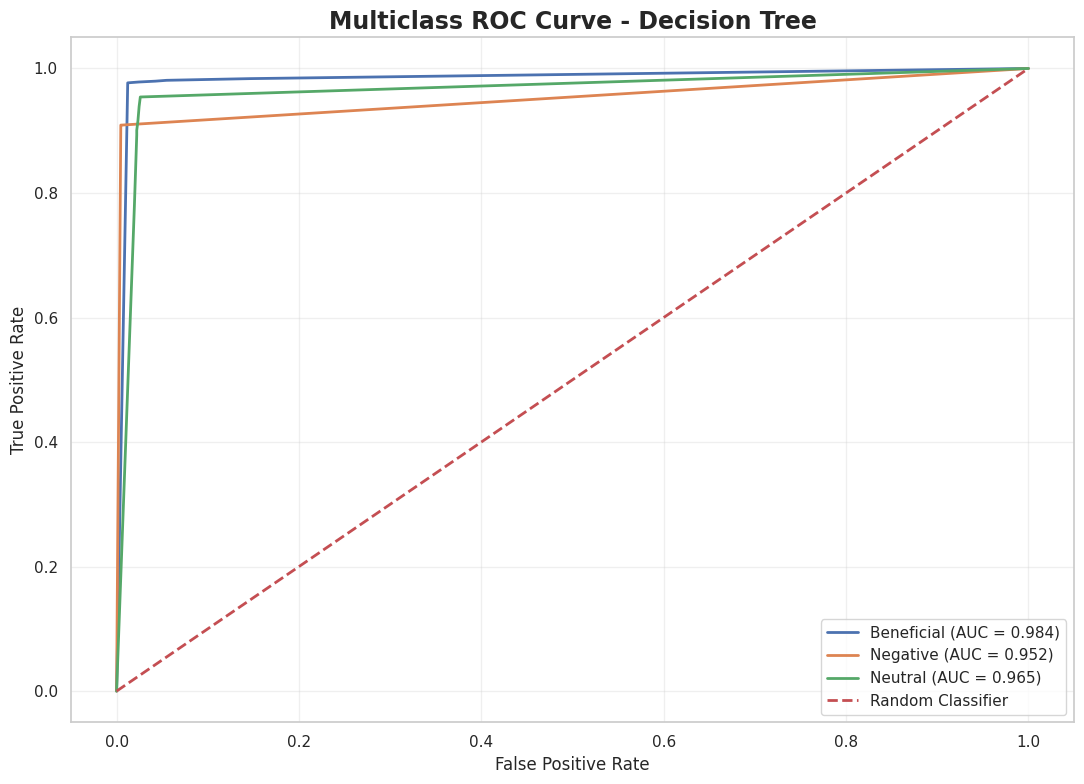

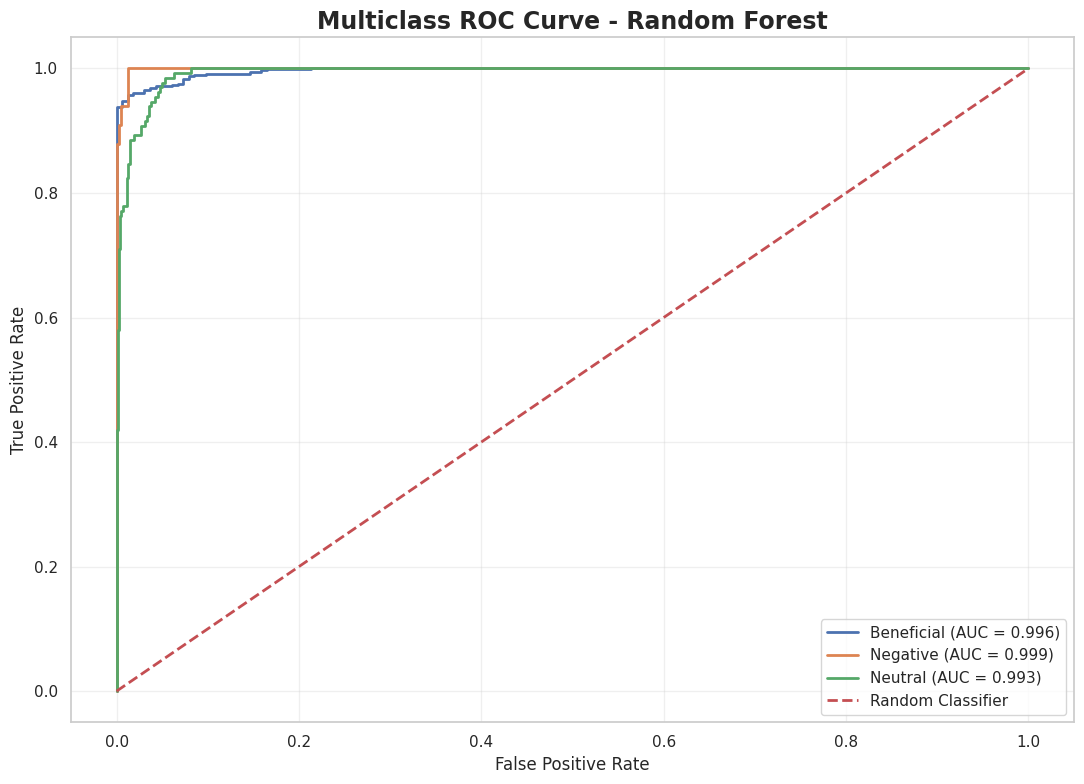

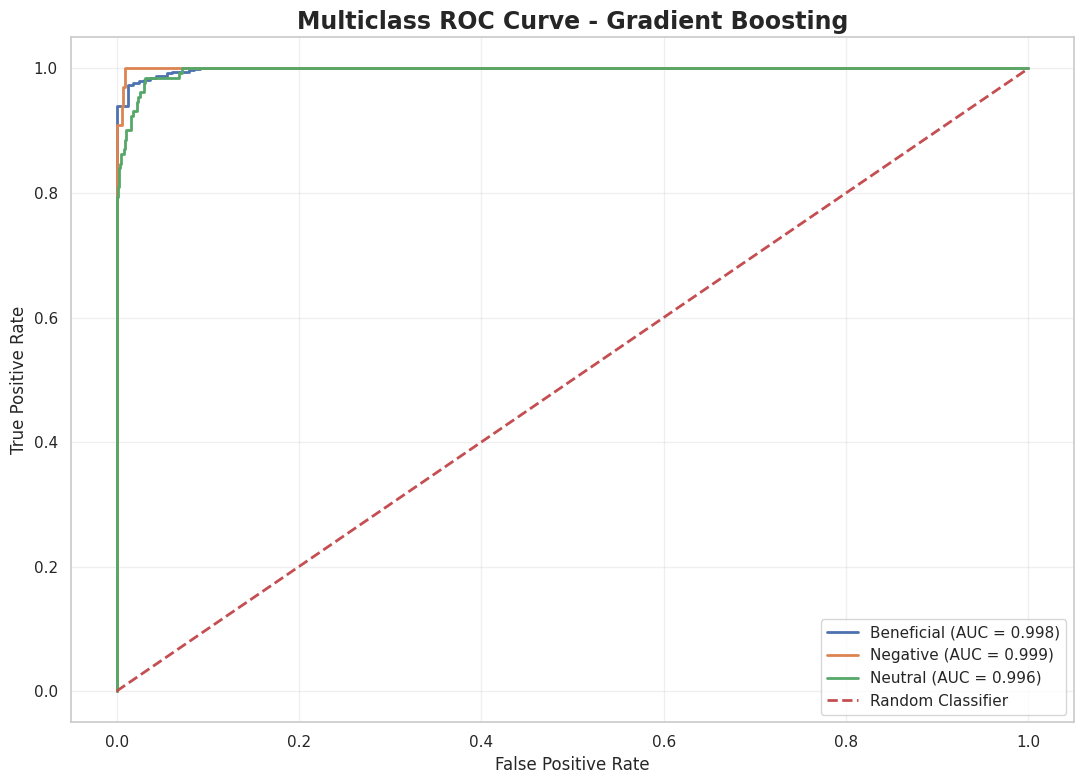

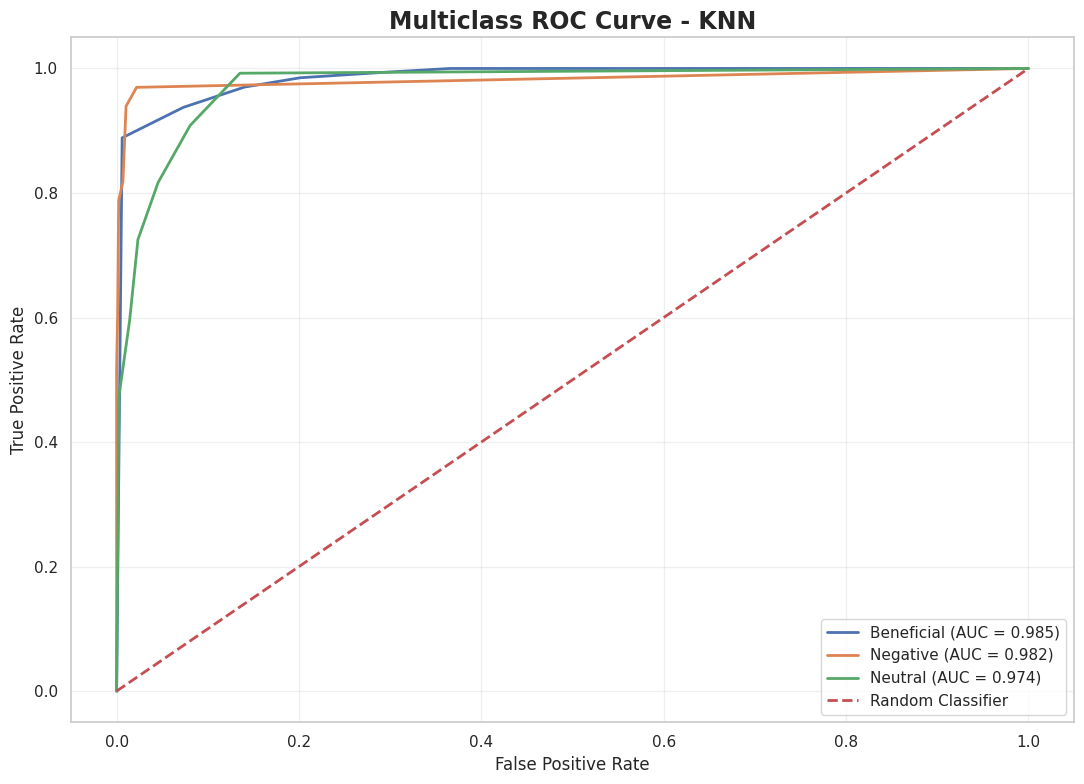

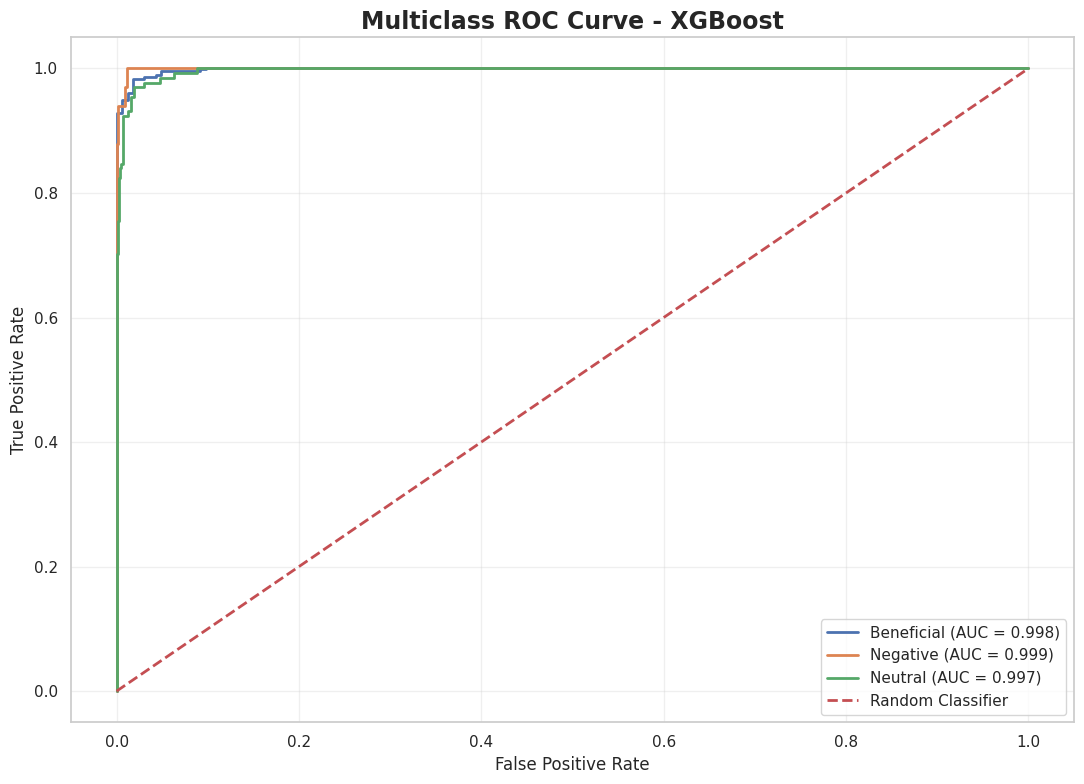

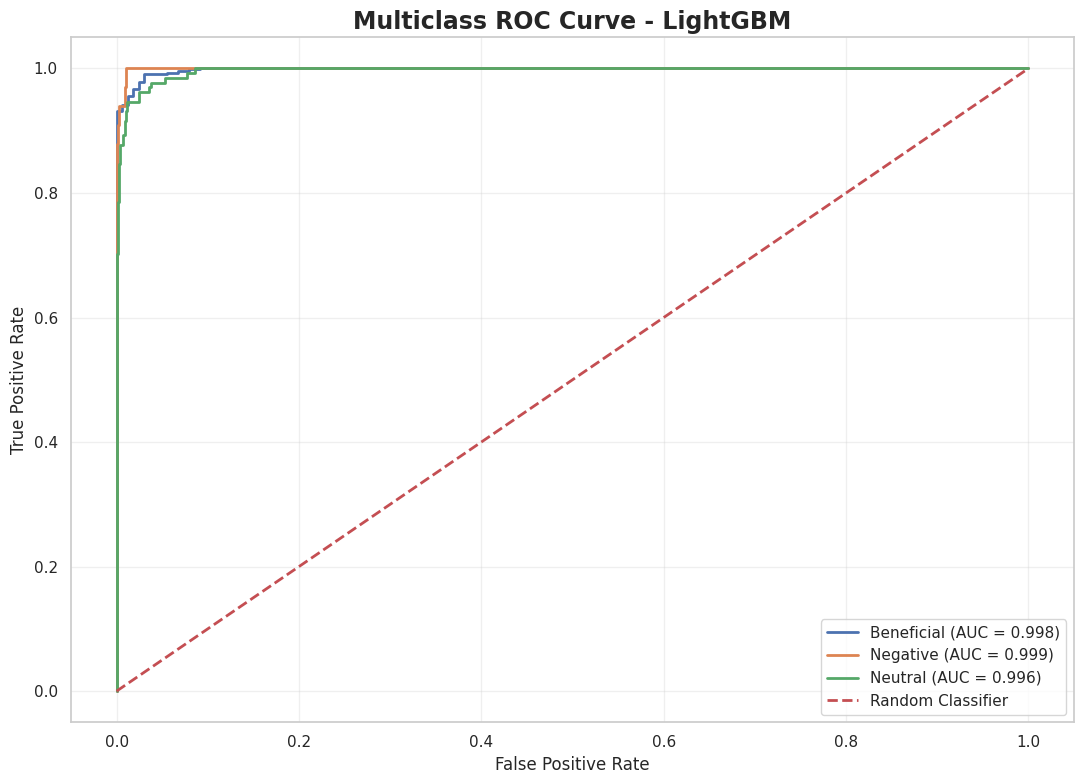

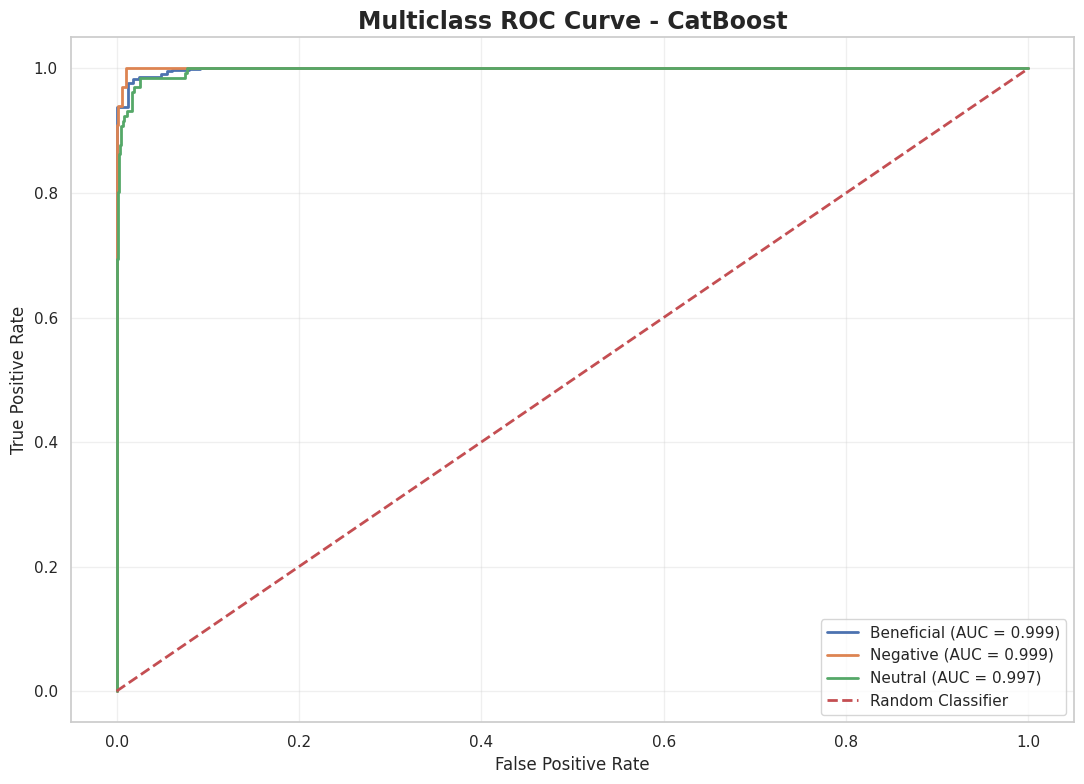

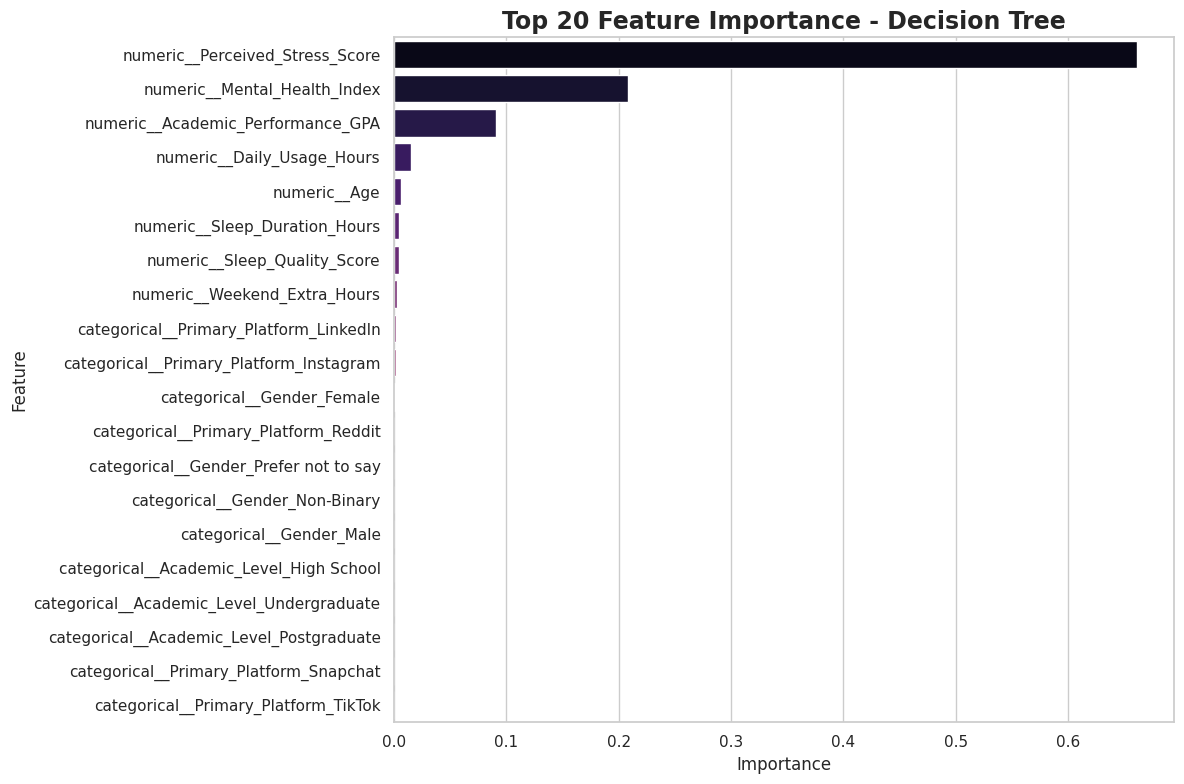

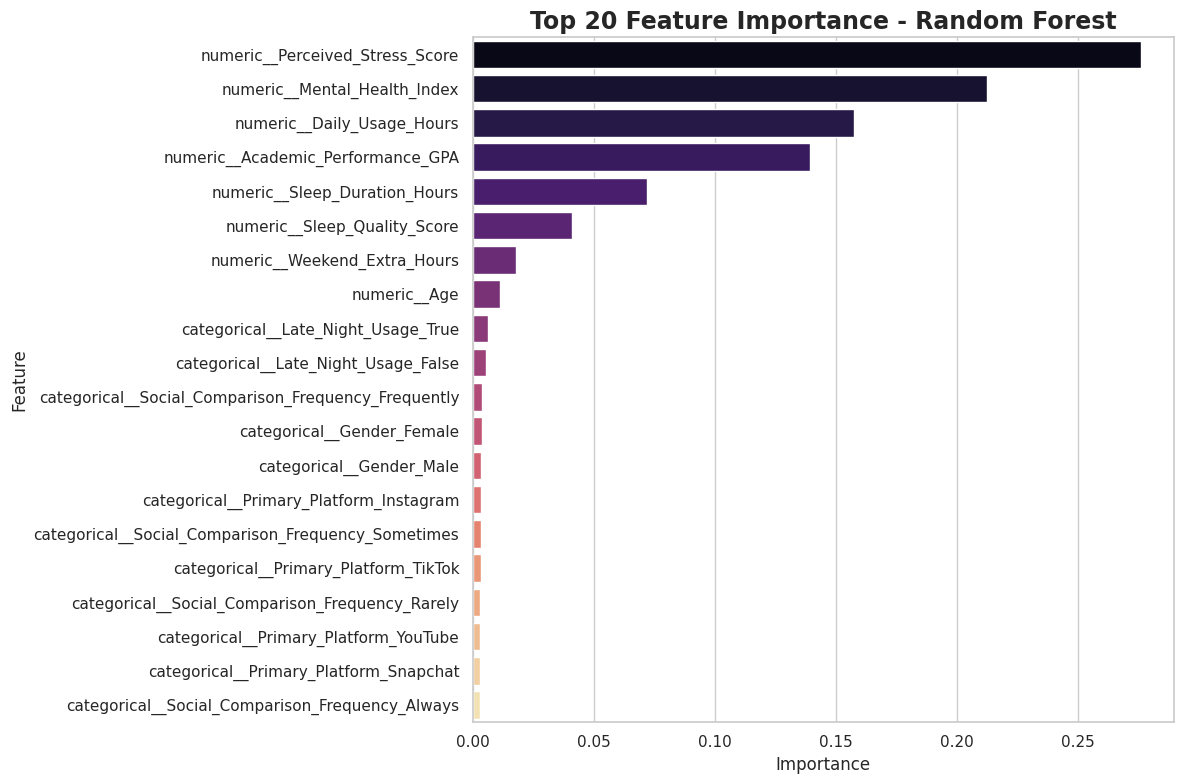

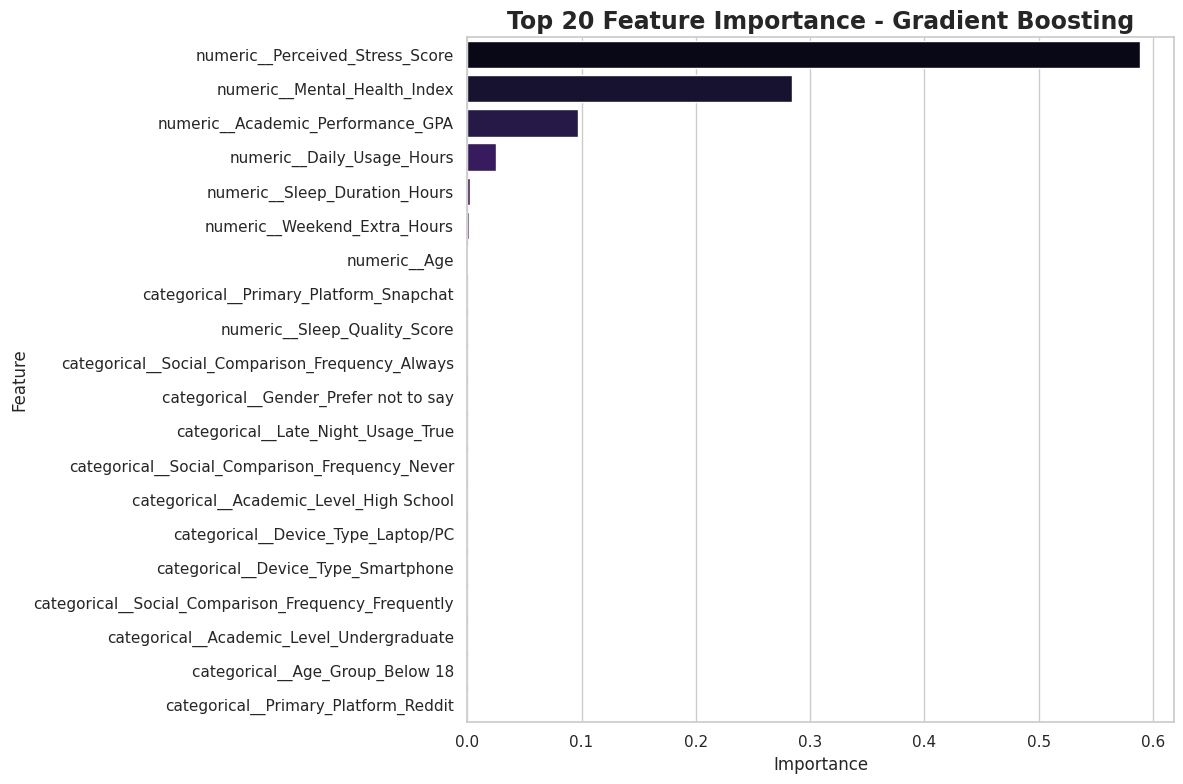

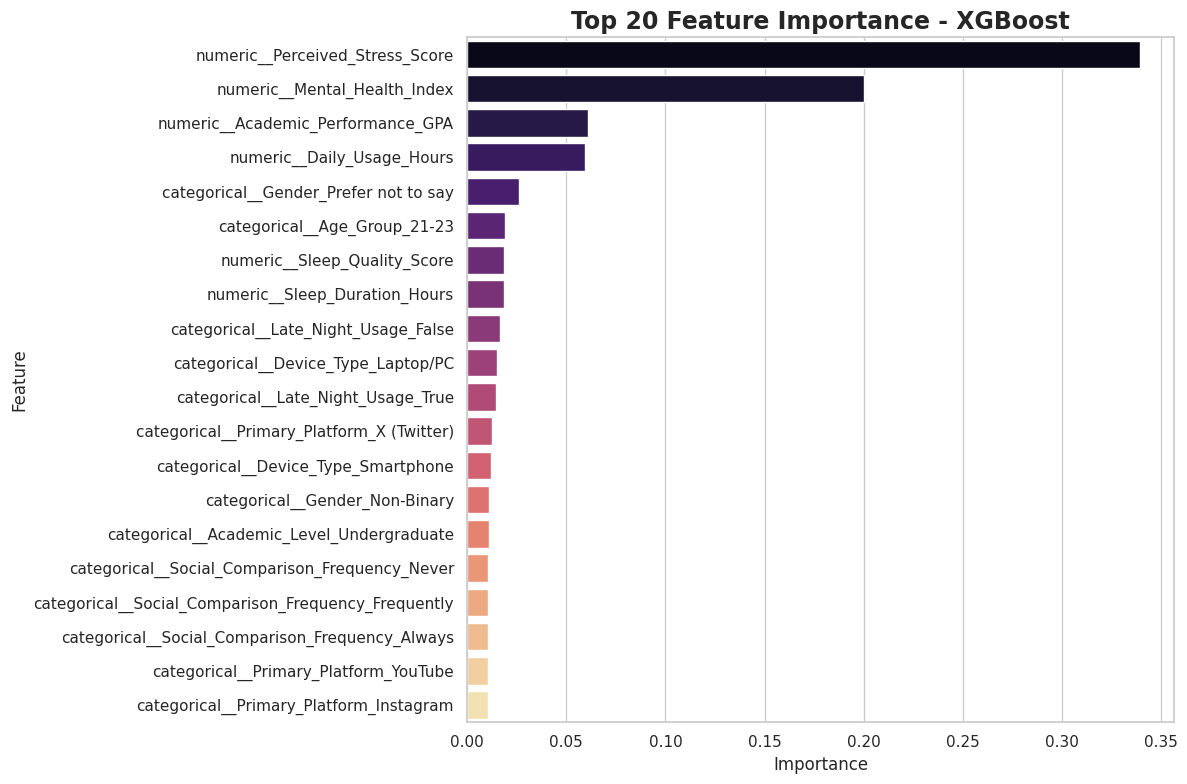

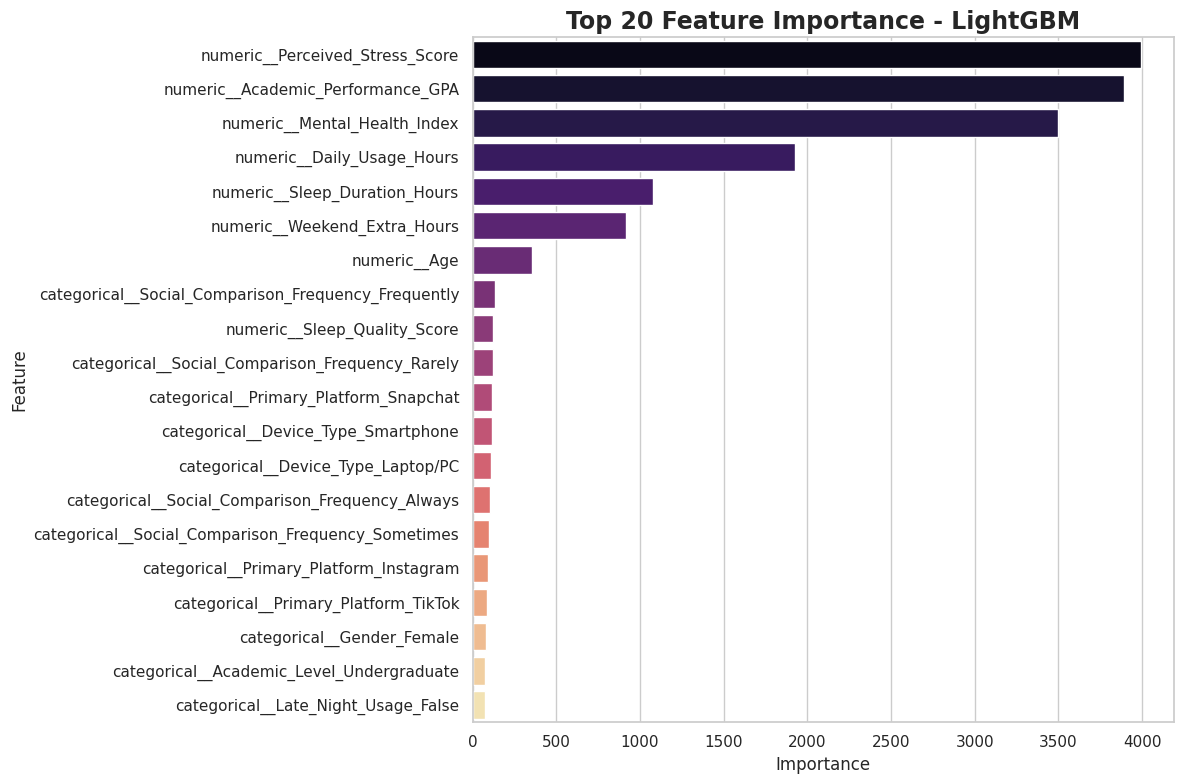

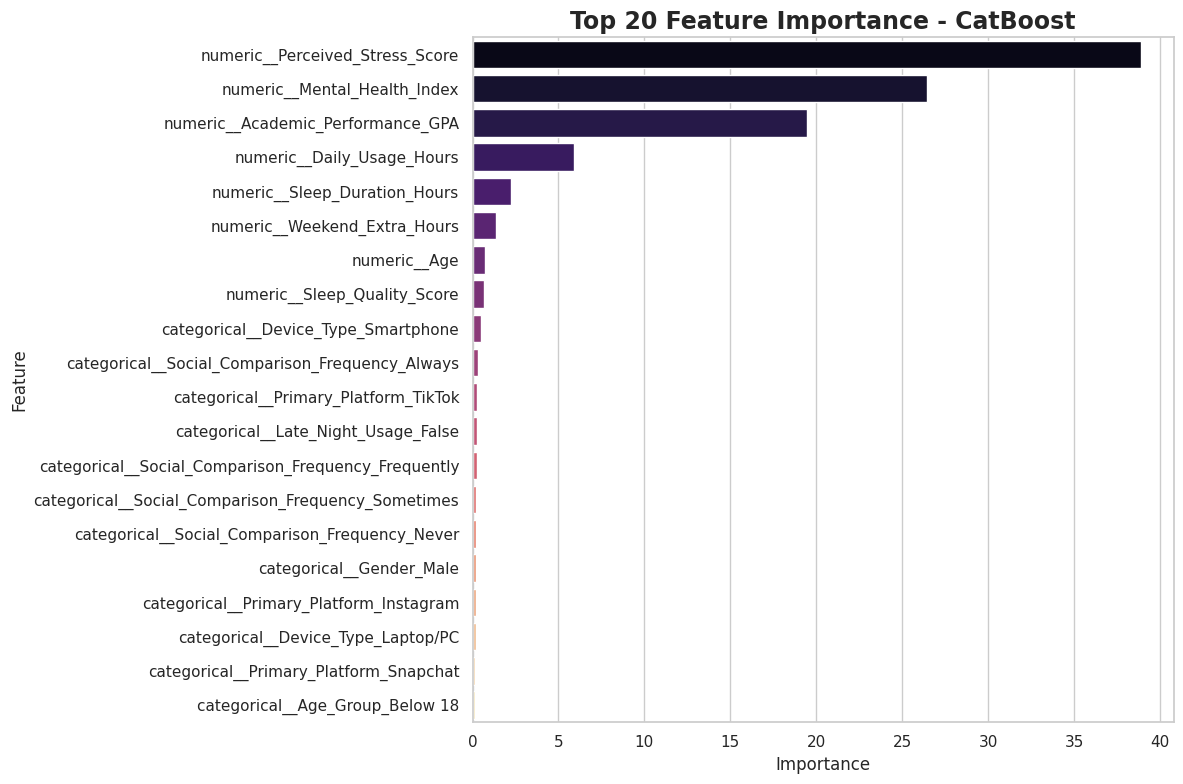

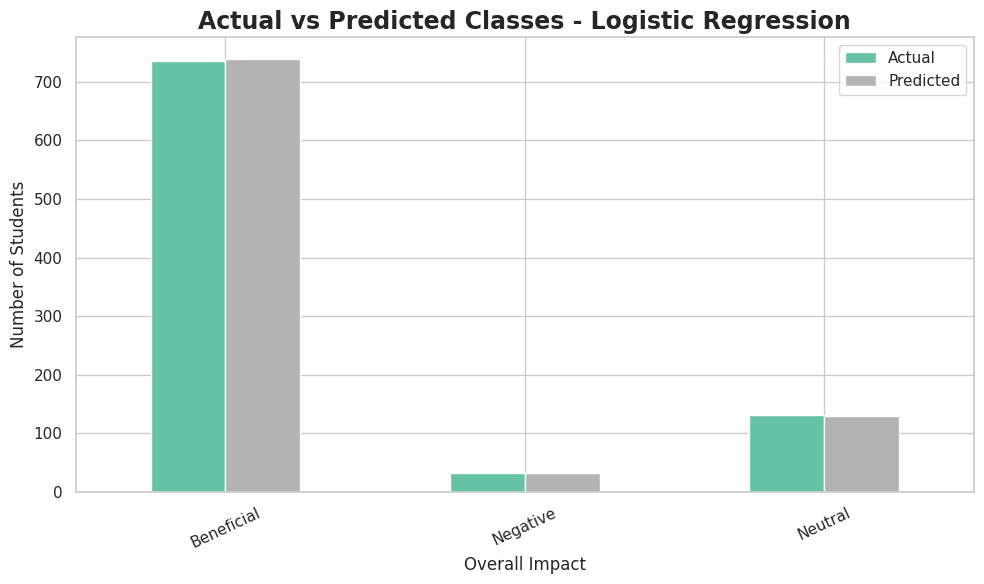


FINAL MODEL PERFORMANCE SUMMARY
Model       : Logistic Regression
Accuracy    : 98.22%
Precision   : 98.21%
Recall      : 98.22%
F1 Score    : 98.21%
ROC AUC     : 99.79%

TARGET LABEL MAPPING
0 = Beneficial
1 = Negative
2 = Neutral

MACHINE LEARNING ANALYSIS COMPLETED SUCCESSFULLY


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Optional models
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
except ImportError:
    lightgbm_available = False

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False


print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)

print(df.columns.tolist())


print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)

print(df.head())


# ============================================================
# 4. CHECK TARGET COLUMN
# ============================================================

target = "Overall_Impact"

if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' was not found in the dataset."
    )


print("\n" + "=" * 80)
print("TARGET VARIABLE")
print("=" * 80)

print("Target:", target)

print("\nTarget Values:")
print(df[target].value_counts(dropna=False))


# ============================================================
# 5. REMOVE DUPLICATE ROWS
# ============================================================

print("\n" + "=" * 80)
print("DUPLICATE CHECK")
print("=" * 80)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")


# ============================================================
# 6. REMOVE ROWS WHERE TARGET IS MISSING
# ============================================================

df = df.dropna(subset=[target]).reset_index(drop=True)


# ============================================================
# 7. REMOVE STUDENT_ID
# ============================================================
#
# Student_ID is an identifier and normally should not be used
# as a predictive feature.
# ============================================================

if "Student_ID" in df.columns:

    df = df.drop(columns=["Student_ID"])

    print("\nStudent_ID removed because it is an identifier.")


# ============================================================
# 8. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[target])
y = df[target].copy()


print("\n" + "=" * 80)
print("FEATURES")
print("=" * 80)

print(X.columns.tolist())


# ============================================================
# 9. LABEL ENCODING TARGET
# ============================================================
#
# Overall_Impact is categorical.
# Example:
#
# Negative -> 0
# Neutral  -> 1
# Positive -> 2
#
# Actual mapping depends on your dataset.
# ============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y.astype(str))

print("\n" + "=" * 80)
print("TARGET LABEL ENCODING")
print("=" * 80)

for original, encoded in zip(
    target_encoder.classes_,
    range(len(target_encoder.classes_))
):
    print(f"{original} --> {encoded}")


print("\nNumber of target classes:", len(target_encoder.classes_))


# ============================================================
# 10. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\n" + "=" * 80)
print("NUMERICAL FEATURES")
print("=" * 80)

print(numeric_features)


print("\n" + "=" * 80)
print("CATEGORICAL FEATURES")
print("=" * 80)

print(categorical_features)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

print(
    "Training percentage:",
    round((len(X_train) / len(X)) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round((len(X_test) / len(X)) * 100, 2),
    "%"
)


# ============================================================
# 12. PREPROCESSING
# ============================================================
#
# Numerical:
#     Median imputation
#     StandardScaler
#
# Categorical:
#     Most frequent imputation
#     OneHotEncoder
#
# This is safer than manually encoding the complete dataset
# before train-test splitting.
# ============================================================

from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 13. DEFINE MODELS
# ============================================================

models = {}


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

models["Logistic Regression"] = LogisticRegression(
    max_iter=2000,
    random_state=42
)


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

models["Decision Tree"] = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

models["Random Forest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

models["Gradient Boosting"] = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

models["KNN"] = KNeighborsClassifier(
    n_neighbors=7
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

if xgboost_available:

    n_classes = len(np.unique(y_encoded))

    if n_classes == 2:

        models["XGBoost"] = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )

    else:

        models["XGBoost"] = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            random_state=42
        )


# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if lightgbm_available:

    n_classes = len(np.unique(y_encoded))

    if n_classes == 2:

        models["LightGBM"] = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            verbosity=-1
        )

    else:

        models["LightGBM"] = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            objective="multiclass",
            num_class=n_classes,
            random_state=42,
            verbosity=-1
        )


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

if catboost_available:

    models["CatBoost"] = CatBoostClassifier(
        iterations=250,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    )


# ============================================================
# 14. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}


print("\n" + "=" * 80)
print("MODEL TRAINING STARTED")
print("=" * 80)


for model_name, model in models.items():

    print("\n" + "-" * 80)
    print("Training:", model_name)
    print("-" * 80)

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability
    if hasattr(pipeline, "predict_proba"):

        y_proba = pipeline.predict_proba(X_test)

    else:

        y_proba = None


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    # --------------------------------------------------------
    # ROC AUC
    # --------------------------------------------------------

    roc_auc = np.nan

    if y_proba is not None:

        try:

            if len(np.unique(y_test)) == 2:

                roc_auc = roc_auc_score(
                    y_test,
                    y_proba[:, 1]
                )

            else:

                roc_auc = roc_auc_score(
                    y_test,
                    y_proba,
                    multi_class="ovr",
                    average="weighted"
                )

        except Exception:

            roc_auc = np.nan


    # Store results

    results.append({
        "Model": model_name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1 Score": f1 * 100,
        "ROC AUC": (
            roc_auc * 100
            if not np.isnan(roc_auc)
            else np.nan
        )
    })


    trained_models[model_name] = pipeline
    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    if not np.isnan(roc_auc):

        print(
            f"ROC AUC   : {roc_auc * 100:.2f}%"
        )


# ============================================================
# 15. MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.2f}%".format,
            "Precision": "{:.2f}%".format,
            "Recall": "{:.2f}%".format,
            "F1 Score": "{:.2f}%".format,
            "ROC AUC": lambda x:
                "N/A"
                if pd.isna(x)
                else f"{x:.2f}%"
        }
    )
)


# ============================================================
# 16. ACCURACY COMPARISON BAR CHART
# ============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(
    max(0, results_df["Accuracy"].min() - 10),
    min(100, results_df["Accuracy"].max() + 5)
)

plt.xticks(rotation=35)

# Add percentage values
for i, value in enumerate(results_df["Accuracy"]):

    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 17. PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics_for_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plot_df = results_df[
    ["Model"] + metrics_for_plot
].copy()

plot_df = plot_df.set_index("Model")


plot_df.plot(
    kind="bar",
    figsize=(15, 8),
    width=0.8,
    colormap="tab10"
)

plt.title(
    "Model Performance Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Score (%)")

plt.xticks(rotation=35)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. CONFUSION MATRIX FOR EACH MODEL
# ============================================================

for model_name in trained_models.keys():

    y_pred = predictions[model_name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

for model_name in trained_models.keys():

    print("\n" + "=" * 80)
    print(f"CLASSIFICATION REPORT - {model_name}")
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )


# ============================================================
# 20. ROC CURVE
# ============================================================
#
# Binary classification:
#     Standard ROC curve
#
# Multiclass classification:
#     One-vs-Rest ROC curve
# ============================================================

n_classes = len(
    np.unique(y_encoded)
)


# ============================================================
# 20A. BINARY ROC CURVES
# ============================================================

if n_classes == 2:

    plt.figure(figsize=(11, 8))

    for model_name in trained_models.keys():

        y_proba = probabilities[model_name]

        if y_proba is None:
            continue

        fpr, tpr, _ = roc_curve(
            y_test,
            y_proba[:, 1]
        )

        roc_auc_value = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} (AUC = {roc_auc_value:.3f})"
        )


    # Random classifier line

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2,
        label="Random Classifier"
    )

    plt.title(
        "ROC Curve - All Machine Learning Models",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 20B. MULTICLASS ROC CURVES
# ============================================================

else:

    from sklearn.preprocessing import label_binarize

    y_test_binary = label_binarize(
        y_test,
        classes=np.arange(n_classes)
    )


    for model_name in trained_models.keys():

        y_proba = probabilities[model_name]

        if y_proba is None:
            continue

        plt.figure(figsize=(11, 8))


        for class_index in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_binary[:, class_index],
                y_proba[:, class_index]
            )

            roc_auc_value = auc(
                fpr,
                tpr
            )

            class_name = target_encoder.classes_[
                class_index
            ]

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f"{class_name} (AUC = {roc_auc_value:.3f})"
            )


        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=2,
            label="Random Classifier"
        )


        plt.title(
            f"Multiclass ROC Curve - {model_name}",
            fontsize=17,
            fontweight="bold"
        )

        plt.xlabel(
            "False Positive Rate"
        )

        plt.ylabel(
            "True Positive Rate"
        )

        plt.legend(
            loc="lower right"
        )

        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================
#
# Random Forest / Decision Tree / Gradient Boosting /
# XGBoost / LightGBM / CatBoost
#
# We extract feature names after preprocessing.
# ============================================================

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]


for model_name in tree_models:

    if model_name not in trained_models:
        continue

    pipeline = trained_models[model_name]

    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        continue


    # Get transformed feature names

    preprocessor_fitted = pipeline.named_steps[
        "preprocessor"
    ]

    try:

        feature_names = (
            preprocessor_fitted
            .get_feature_names_out()
        )

    except Exception:

        feature_names = [
            f"Feature_{i}"
            for i in range(
                len(
                    model.feature_importances_
                )
            )
        ]


    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })


    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(20)


    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title(
        f"Top 20 Feature Importance - {model_name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

# Select model with highest accuracy
best_model_name = results_df.iloc[0]["Model"]

best_predictions = predictions[
    best_model_name
]


actual_counts = pd.Series(
    y_test
).value_counts().sort_index()

predicted_counts = pd.Series(
    best_predictions
).value_counts().sort_index()


comparison = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)


comparison.index = target_encoder.inverse_transform(
    comparison.index.astype(int)
)


comparison.plot(
    kind="bar",
    figsize=(10, 6),
    colormap="Set2"
)

plt.title(
    f"Actual vs Predicted Classes - {best_model_name}",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Overall Impact")
plt.ylabel("Number of Students")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 23. FINAL BEST MODEL SUMMARY
# ============================================================

best_row = results_df.iloc[0]


print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

print(
    f"Model       : {best_row['Model']}"
)

print(
    f"Accuracy    : {best_row['Accuracy']:.2f}%"
)

print(
    f"Precision   : {best_row['Precision']:.2f}%"
)

print(
    f"Recall      : {best_row['Recall']:.2f}%"
)

print(
    f"F1 Score    : {best_row['F1 Score']:.2f}%"
)

if not pd.isna(best_row["ROC AUC"]):

    print(
        f"ROC AUC     : {best_row['ROC AUC']:.2f}%"
    )


# ============================================================
# 24. TARGET LABEL MAPPING
# ============================================================

print("\n" + "=" * 80)
print("TARGET LABEL MAPPING")
print("=" * 80)

for index, class_name in enumerate(
    target_encoder.classes_
):

    print(
        f"{index} = {class_name}"
    )


# ============================================================
# 25. END
# ============================================================

print("\n" + "=" * 80)
print("MACHINE LEARNING ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 80)

## Thank you..pls upvote!!!!!!!!!